<a href="https://colab.research.google.com/github/fxrdhan/ML_scikit-learn_Cookbook_O-Reilly/blob/main/Chapter_02_Pre_Model_Workflow_and_Data_Preprocessing/Chapter_02_Pre_Model_Workflow_and_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Pre-Model Workflow and Data Preprocessing

| | |
|---|---|
| **Book** | *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing, 2025) |
| **Library version targeted by the book** | scikit-learn 1.5 |
| **Version used to run this notebook** | scikit-learn 1.9.1 on Python 3.12 (printed by the setup cell) |
| **What this notebook contains** | reproduction of every code listing in the chapter and of the official exercise solution, chapter and recipe summaries, theoretical deep-dives, and extra experiments |

## Chapter overview

"Garbage in, garbage out": the quality of the data decides how good a model can become, and preparing data is a recurring task rather than a one-off step, because data keep changing. Chapter 2 is the book's toolbox for that preparation. It shows how to:

* recognise the **data problems** that hurt models — missing values, outliers, categorical variables, features on different scales and data leakage;
* **impute** missing values with `SimpleImputer`, `KNNImputer` and `IterativeImputer`;
* **scale** features with `StandardScaler`, `MinMaxScaler` and `Normalizer`;
* **encode** categorical variables with `OneHotEncoder`, `LabelEncoder` and `ColumnTransformer`;
* chain everything into a **`Pipeline`**, split the data *before* transforming it, and visualise the pipeline;
* **engineer features** — create them with `PolynomialFeatures` and `KBinsDiscretizer`, and select them with `RFE` and `SelectFromModel`;
* put it all together in a **practical exercise** on the California Housing dataset.

### Recipes in this chapter

| # | Recipe | Code in the book | What this notebook adds |
|---|---|---|---|
| 1 | The impact of raw data on model performance | No | Label noise, irrelevant features and outliers measured on real models |
| 2 | Handling missing data | Yes, 4 listings | Missingness mechanisms, how each imputer works, imputation accuracy on correlated data |
| 3 | Scaling techniques | Yes, 3 listings | Formulas checked by hand, outlier robustness, which models need scaling |
| 4 | Encoding categorical variables | Yes, 4 listings | Ordinal vs. nominal encoding done right, unseen categories, the dummy-variable trap |
| 5 | Introduction to pipelines in scikit-learn | Yes, 2 listings | A hidden target leak in the book's example, preprocessing tuned as a hyperparameter |
| 6 | Feature engineering | Yes, 4 listings | Polynomial and binning theory, feature selection checked against a known ground truth |
| 7 | Practical exercise on data preprocessing | Official solution | Extra metrics, baselines, a scale-invariance check and a residual view |

### How to read this notebook

Every recipe has the same structure:

1. **Summary** — what the book says, condensed.
2. **Theory** — the ideas behind it: math, algorithms and design reasoning.
3. **Book code** — the listing reproduced from the book (page numbers refer to the printed edition), followed by an **output analysis**.
4. **Extra** — experiments written for this notebook to make the theory concrete. They are *not* part of the book.

Every code cell starts with a label comment: `# BOOK CODE` for a listing reproduced from the book, `# EXTRA` for code written for this notebook.

## 0. Setup

The book's own examples use small synthetic datasets generated with `np.random.seed(2024)`. The extra experiments use datasets bundled with scikit-learn (`load_breast_cancer`, `load_wine`, `load_diabetes`) or synthetic data with fixed seeds. Only the practical exercise needs a download: `fetch_california_housing()` downloads the California Housing data once and caches it in `~/scikit_learn_data`.

> The extra experiments use APIs introduced in scikit-learn 1.6. If the version check below fails, run `pip install -U scikit-learn` and restart the kernel.

In [1]:
import platform
import time
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

print(f"Python       : {platform.python_version()}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")

sk_version = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
assert sk_version >= (1, 6), "This notebook needs scikit-learn >= 1.6 -> pip install -U scikit-learn"

# Global seed: makes code that does not set random_state (such as the exercise solution) reproducible
np.random.seed(0)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# A quiet, colour-blind-safe style used by every figure in this notebook
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua (checked for colour-vision deficiency)
INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 10,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_SOFT, "ytick.labelcolor": INK_SOFT,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2, "legend.frameon": False, "legend.labelcolor": INK_SOFT,
    "figure.dpi": 110, "font.size": 10,
})

Python       : 3.12.3
scikit-learn : 1.9.1
NumPy        : 2.5.3
pandas       : 3.0.6
Matplotlib   : 3.11.2


---
## 1. The impact of raw data on model performance

### Summary

* Models learn patterns from data, so flawed inputs — **missing data, outliers or irrelevant features** — reduce their ability to generalise to unseen data. A model trained on noisy or biased data makes inaccurate predictions and leads to poor decisions.
* If missing values are not handled, a model either ignores the affected records or makes wrong assumptions about them, which skews what it learns.
* The book lists the most common data issues:
  * **Missing data** — from collection errors, system failures or corruption; handled with `SimpleImputer()` or `KNNImputer()`.
  * **Outliers** — distort statistics; detected with z-scores or tamed with `RobustScaler()`. They can also be valuable evidence of rare events.
  * **Categorical variables** — most algorithms need numbers, so they are converted with `OneHotEncoder()` or `LabelEncoder()`.
  * **Feature scaling** — different scales hurt convergence and distance-based models such as k-NN; fixed with `StandardScaler()` or `MinMaxScaler()`.
  * **Data leakage** — information from outside the training data inflates performance metrics; prevented by separating training and test data during preprocessing (a central concern in MLOps, where data arrive as streams).
* scikit-learn's cleaning tools include `Pipeline()`, `ColumnTransformer()` and `sklearn.feature_selection` (`SelectFromModel()`, recursive feature elimination). Fewer features usually means a more interpretable model: as complexity grows, interpretability shrinks.

> The book gives no code for this recipe; the experiments below measure each problem on real models.

### Theory: why bad data cost accuracy

**Where the error comes from.** For squared loss, the expected error of a model $\hat f$ at a point $\mathbf{x}$ decomposes into three parts:

$$\mathbb{E}\big[(y - \hat f(\mathbf{x}))^2\big] = \underbrace{\big(\mathbb{E}[\hat f(\mathbf{x})] - f(\mathbf{x})\big)^2}_{\text{bias}^2} + \underbrace{\operatorname{Var}\big[\hat f(\mathbf{x})\big]}_{\text{variance}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

Each data problem attacks one of these terms:

| Data problem | What it does |
|---|---|
| Noisy labels | Raises the noise the model must see through; with enough corruption the learned boundary moves to the wrong place (bias) |
| Irrelevant features | Add variance; for distance-based models they also drown the useful dimensions, because random coordinates add the same amount to every distance |
| Outliers | Under squared loss a residual $r$ costs $r^2$, so one extreme point can pull the whole fit towards itself |
| Missing values | Shrink the usable sample and, depending on *why* values are missing, bias what is learned (recipe 2) |
| Different scales | Large-range features dominate distances and penalties (recipe 3) |
| Leakage | Does not change the model but makes its evaluation optimistic (recipe 5) |

**Two rules for flagging outliers.**

* *Z-score rule:* flag $x$ when $|z| = |x - \bar x| / s > 3$. Simple, but the mean $\bar x$ and standard deviation $s$ are themselves pulled by the outliers, which can hide them (the *masking* effect).
* *IQR rule (Tukey's fences):* flag $x$ outside $[Q_1 - 1.5\,\text{IQR},\ Q_3 + 1.5\,\text{IQR}]$, where $\text{IQR} = Q_3 - Q_1$. Quartiles barely move when a few points are extreme, so this rule is robust.

**Robust losses.** Instead of deleting outliers, a model can use a loss that grows more slowly for large residuals. The *Huber loss* (used by `HuberRegressor`) is quadratic for small residuals and linear for large ones:

$$L_\varepsilon(r) = \begin{cases} \tfrac{1}{2} r^2 & |r| \le \varepsilon \\ \varepsilon |r| - \tfrac{1}{2}\varepsilon^2 & |r| > \varepsilon \end{cases}$$

so an outlier's influence on the fit is bounded.

,share of flipped labels,test accuracy,std (10 seeds)
0,0.00,0.959,0.000
1,0.05,0.950,0.011
2,0.10,0.939,0.011
3,0.20,0.922,0.015
4,0.30,0.879,0.028
5,0.40,0.784,0.051
6,0.45,0.661,0.062


,irrelevant features added,CV accuracy
0,0,0.961
1,5,0.944
2,10,0.955
3,25,0.904
4,50,0.865
5,100,0.820


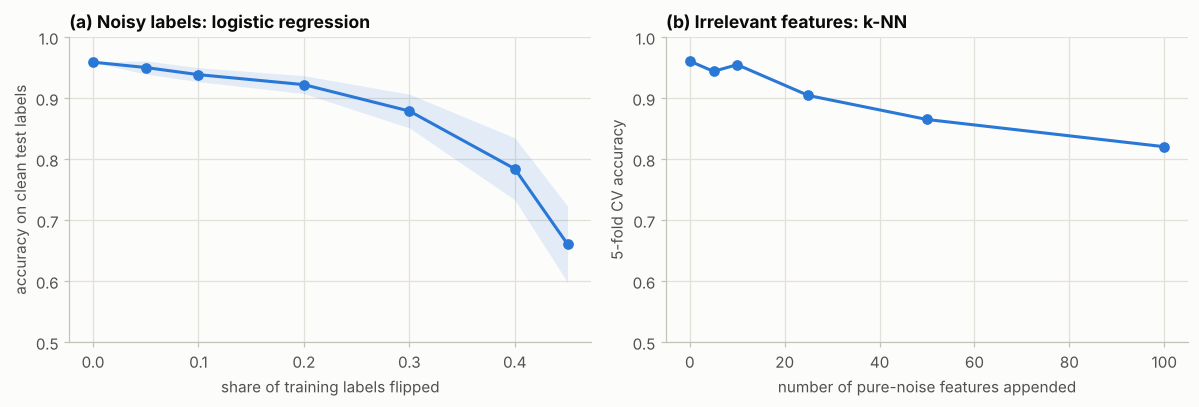

In [2]:
# EXTRA: "Garbage in, garbage out" measured -- (a) noisy labels, (b) irrelevant features
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# (a) Flip a growing share of the TRAINING labels, always evaluate on clean test labels
X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(X_bc, y_bc, test_size=0.3, stratify=y_bc, random_state=0)
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45]
label_noise = []
for share in noise_levels:
    scores = []
    for seed in range(10):
        rng = np.random.default_rng(seed)
        y_noisy = y_bc_tr.copy()
        flip = rng.choice(len(y_noisy), int(share * len(y_noisy)), replace=False)
        y_noisy[flip] = 1 - y_noisy[flip]
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_bc_tr, y_noisy)
        scores.append(model.score(X_bc_te, y_bc_te))
    label_noise.append((share, np.mean(scores), np.std(scores)))
label_noise = pd.DataFrame(label_noise, columns=["share of flipped labels", "test accuracy", "std (10 seeds)"])

# (b) Append columns of pure noise to the wine data and cross-validate k-NN
X_wine, y_wine = load_wine(return_X_y=True)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
rng = np.random.default_rng(0)
noise_feats = []
for k in [0, 5, 10, 25, 50, 100]:
    X_k = np.column_stack([X_wine, rng.normal(size=(len(X_wine), k))]) if k else X_wine
    acc = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), X_k, y_wine, cv=cv5).mean()
    noise_feats.append((k, acc))
noise_feats = pd.DataFrame(noise_feats, columns=["irrelevant features added", "CV accuracy"])
display(label_noise.round(3), noise_feats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(label_noise.iloc[:, 0], label_noise.iloc[:, 1], color=PALETTE[0], marker="o", markersize=6)
ax.fill_between(label_noise.iloc[:, 0], label_noise.iloc[:, 1] - label_noise.iloc[:, 2],
                label_noise.iloc[:, 1] + label_noise.iloc[:, 2], color=PALETTE[0], alpha=0.12, linewidth=0)
ax.set(xlabel="share of training labels flipped", ylabel="accuracy on clean test labels",
       title="(a) Noisy labels: logistic regression", ylim=(0.5, 1.0))
ax = axes[1]
ax.plot(noise_feats.iloc[:, 0], noise_feats.iloc[:, 1], color=PALETTE[0], marker="o", markersize=6)
ax.set(xlabel="number of pure-noise features appended", ylabel="5-fold CV accuracy",
       title="(b) Irrelevant features: k-NN", ylim=(0.5, 1.0))
plt.tight_layout()
plt.show()

**Output analysis.** Both panels show "garbage in, garbage out" in numbers:

* **(a)** Logistic regression is fairly tolerant of a few wrong labels, but accuracy erodes steadily and collapses as the flipped share approaches 50 % — at that point the labels carry almost no information about the classes, so no learner can recover the boundary.
* **(b)** The same 13 wine measurements become harder to use as pure-noise columns are appended: every random column adds about the same amount to every distance, so the neighbours k-NN finds are increasingly random. Nothing about the useful features changed — only irrelevant inputs were added — which is why feature selection (recipe 6) matters.

z-score of the corrupted record : -4.38  (|z| > 3 -> flagged)
Tukey fences                   : [-5.6, 33.0]  -> flagged rows: [30]
slope: OLS clean data = 2.031 | OLS with outlier = 1.182 | Huber with outlier = 2.007


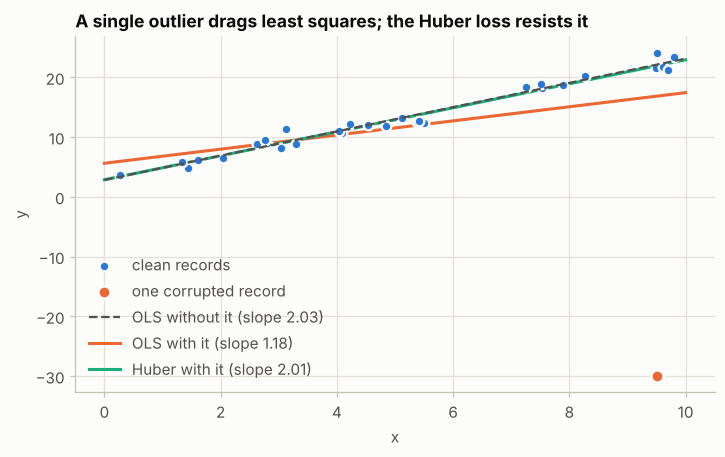

In [3]:
# EXTRA: One outlier versus least squares -- detection rules and a robust alternative
from sklearn.linear_model import HuberRegressor, LinearRegression

rng = np.random.default_rng(1)
x_line = rng.uniform(0, 10, 30)
y_line = 3 + 2 * x_line + rng.normal(0, 1, 30)            # true slope = 2
x_out, y_out = np.append(x_line, 9.5), np.append(y_line, -30.0)  # one corrupted record

z_scores = (y_out - y_out.mean()) / y_out.std()
q1, q3 = np.percentile(y_out, [25, 75])
iqr = q3 - q1
print(f"z-score of the corrupted record : {z_scores[-1]:.2f}  (|z| > 3 -> flagged)")
print(f"Tukey fences                   : [{q1 - 1.5 * iqr:.1f}, {q3 + 1.5 * iqr:.1f}]  -> flagged rows:",
      np.flatnonzero((y_out < q1 - 1.5 * iqr) | (y_out > q3 + 1.5 * iqr)))

ols_clean = LinearRegression().fit(x_line.reshape(-1, 1), y_line)
ols_dirty = LinearRegression().fit(x_out.reshape(-1, 1), y_out)
huber = HuberRegressor().fit(x_out.reshape(-1, 1), y_out)
print(f"slope: OLS clean data = {ols_clean.coef_[0]:.3f} | OLS with outlier = {ols_dirty.coef_[0]:.3f} | "
      f"Huber with outlier = {huber.coef_[0]:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
grid_x = np.linspace(0, 10, 50).reshape(-1, 1)
ax.scatter(x_line, y_line, s=40, color=PALETTE[0], edgecolor=SURFACE, linewidth=1.5, zorder=3, label="clean records")
ax.scatter([9.5], [-30.0], s=70, color=PALETTE[1], edgecolor=SURFACE, linewidth=2, zorder=4, label="one corrupted record")
ax.plot(grid_x, ols_clean.predict(grid_x), color=INK_SOFT, linewidth=1.5, linestyle="--", zorder=5,
        label=f"OLS without it (slope {ols_clean.coef_[0]:.2f})")
ax.plot(grid_x, ols_dirty.predict(grid_x), color=PALETTE[1], label=f"OLS with it (slope {ols_dirty.coef_[0]:.2f})")
ax.plot(grid_x, huber.predict(grid_x), color=PALETTE[2], label=f"Huber with it (slope {huber.coef_[0]:.2f})")
ax.set(xlabel="x", ylabel="y", title="A single outlier drags least squares; the Huber loss resists it")
ax.legend(loc="lower left")
plt.show()

**Output analysis.** One corrupted record out of 31 is enough to cut the least-squares slope almost in half, because its huge residual is *squared*. Both detection rules flag it (its z-score is far beyond 3 and it lies outside Tukey's fences), and the Huber regressor — whose loss grows only linearly for large residuals — recovers essentially the true slope of 2 without deleting anything. Whether to delete, cap (recipe 4 of Chapter 1 built such a clipper) or down-weight an outlier depends on whether it is an error or a rare but real event, as the book notes.

---
## 2. Handling missing data

### Summary

* Missing values come from human error, technical failures or corrupted data. Most algorithms cannot handle them and most scikit-learn estimators refuse to run when they find them, so they must be dealt with before training.
* With large datasets, rows with missing values can sometimes be **dropped** with little impact, but often that is not viable. The alternative is **imputation**: filling the gaps with estimates computed from the available data.
* The recipe builds a toy dataset — 20 samples, 10 uniform random features, about 20 % of the values removed at random — and applies three imputers:
  * `SimpleImputer()` replaces missing entries with a statistic of the column: mean, median or most frequent value;
  * `KNNImputer()` uses the samples closest to the incomplete one to estimate the missing value;
  * `IterativeImputer()` (experimental) models each incomplete feature as a regression on the other features, round-robin.
* Choosing a strategy depends on the data type (mean/median for numbers, mode for categories), the distribution, the **pattern** of missingness (completely at random or not) and the **amount** missing. Tree-based models such as decision trees and random forests can work with missing values directly.

### Theory: why values are missing, and what each imputer does

**Missingness mechanisms** (Rubin, 1976) decide which methods are safe:

| Mechanism | Probability that a value is missing depends on | Example | Consequence |
|---|---|---|---|
| **MCAR** — missing completely at random | nothing | a sensor drops readings at random | dropping or simple imputation is unbiased (but wasteful) |
| **MAR** — missing at random | other, *observed* variables | older patients skip an online form | model-based imputation using the observed variables can correct the bias |
| **MNAR** — missing not at random | the missing value itself | high earners do not report income | no imputer can fully fix it; adding a missingness indicator lets the model learn from the pattern |

**Dropping rows is expensive.** If each of $p$ features is missing independently with probability $m$, a row is complete with probability $(1-m)^p$. For the book's toy data ($m = 0.2$, $p = 10$): $0.8^{10} \approx 0.107$ — about 9 out of 10 rows would be thrown away.

**`SimpleImputer`** fills each column with one number learned from the training data: the mean (sensitive to outliers), the median (robust), the most frequent value (also works for categories) or a constant. It is fast, but every imputed value sits exactly at the centre, so the column's variance shrinks — by a factor of about $(1-m)$ when a share $m$ is imputed — and its correlations with other columns weaken.

**`KNNImputer`** (Troyanskaya et al., 2001) finds, for each incomplete sample, the `n_neighbors` closest training samples that *have* the missing feature, and fills the gap with the **mean** of their values (or a distance-weighted mean). Distances skip missing coordinates and are rescaled for them (the *nan-Euclidean* distance):

$$d(\mathbf{x}, \mathbf{z}) = \sqrt{\frac{p}{|P|}\sum_{j \in P} (x_j - z_j)^2}, \qquad P = \{\, j : x_j \text{ and } z_j \text{ both observed} \,\}.$$

*A precision:* the book describes the imputed value as the "majority label" among the neighbours; for numeric data the imputer actually takes the neighbours' average.

**`IterativeImputer`** follows the MICE idea (*multivariate imputation by chained equations*, van Buuren & Groothuis-Oudshoorn, 2011):

1. start by filling every gap with the column mean;
2. for each feature with missing values in turn, fit a regressor (default `BayesianRidge`) that predicts it from **all the other features** — using their current, partly imputed values — on the rows where it is observed, then predict its missing entries;
3. repeat the round (`max_iter`, default 10) until the imputations stop changing (`tol`).

It exploits correlations between features, so it helps exactly when features are related — and cannot help when they are independent, as in the book's toy data.

**Practical rules.**

* Fit imputers on the training data only (inside a `Pipeline`), like any other transformer.
* `add_indicator=True` appends a 0/1 column per incomplete feature, which matters under MNAR.
* `KNNImputer` and `IterativeImputer` need numeric input; categorical columns are imputed with `SimpleImputer(strategy="most_frequent")` or encoded first.
* Some estimators accept missing values natively — `HistGradientBoostingClassifier/Regressor`, and in recent versions decision trees and random forests — so imputation is not always required.
* *A precision on the book's guideline:* it reads "when >5 % of your dataset contains missing values, `SimpleImputer()` is a good candidate", which, given the moderate (5–10 %) and >10 % cases that follow, presumably means *less than* 5 %.

In [4]:
# BOOK CODE: Handling missing data -- getting ready (pp. 16-17)
# Load libraries
import numpy as np
import pandas as pd

# Create a larger sample dataset with missing values
np.random.seed(2024)  # For reproducibility
n_samples = 20
n_features = 10

# Generate random data
data = {
    f"Feature{i+1}": np.random.uniform(0, 100, n_samples) for i in range(n_features)
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Randomly introduce missing values (approximately 20% of the data)
for column in df.columns:
    mask = np.random.random(n_samples) < 0.2
    df.loc[mask, column] = np.nan

# Display the DataFrame with missing values
display(df)

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,58.801452,NaN,42.009814,34.680397,49.962259,NaN,NaN,89.954588,41.152421,NaN
1,69.910875,9.554215,6.436369,31.287816,37.966499,NaN,82.005649,NaN,75.797616,91.382492
2,NaN,96.090974,59.643269,84.710402,NaN,84.109027,NaN,70.288128,1.778343,4.117690
3,NaN,25.176729,83.732372,88.023110,16.886931,97.205554,84.696823,NaN,NaN,80.077973
4,20.501895,NaN,89.248639,67.655865,58.635861,78.225721,60.911562,NaN,65.114243,99.119187
5,10.606287,76.825393,20.052744,5.367515,NaN,19.703051,34.423301,93.399494,72.206680,12.640276
6,72.724014,79.792340,50.239523,55.921377,6.191019,NaN,22.966899,21.049022,57.358544,14.302591
7,NaN,NaN,89.538184,69.451294,NaN,47.885551,NaN,33.620401,99.685711,6.683138
8,47.384570,NaN,25.592093,82.419730,73.414540,61.663700,29.172571,65.946718,61.005155,34.052747
9,44.829582,38.165095,NaN,31.142866,28.865545,NaN,41.004459,41.460336,50.236236,NaN


In [5]:
# BOOK CODE: Using the SimpleImputer() class (p. 17)
# Load libraries
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer and set the strategy to "mean", "median", or "most_frequent"
imputer = SimpleImputer(strategy="mean")

# Fit and transform the data
imputed_data = imputer.fit_transform(df)
imputed_df = pd.DataFrame(imputed_data, columns=df.columns)
imputed_df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,58.801452,53.864661,42.009814,34.680397,49.962259,57.822964,51.145011,89.954588,41.152421,48.400044
1,69.910875,9.554215,6.436369,31.287816,37.966499,57.822964,82.005649,50.715003,75.797616,91.382492
2,52.558605,96.090974,59.643269,84.710402,46.055883,84.109027,51.145011,70.288128,1.778343,4.117690
3,52.558605,25.176729,83.732372,88.023110,16.886931,97.205554,84.696823,50.715003,60.616723,80.077973
4,20.501895,53.864661,89.248639,67.655865,58.635861,78.225721,60.911562,50.715003,65.114243,99.119187
5,10.606287,76.825393,20.052744,5.367515,46.055883,19.703051,34.423301,93.399494,72.206680,12.640276
6,72.724014,79.792340,50.239523,55.921377,6.191019,57.822964,22.966899,21.049022,57.358544,14.302591
7,52.558605,53.864661,89.538184,69.451294,46.055883,47.885551,51.145011,33.620401,99.685711,6.683138
8,47.384570,53.864661,25.592093,82.419730,73.414540,61.663700,29.172571,65.946718,61.005155,34.052747
9,44.829582,38.165095,52.897507,31.142866,28.865545,57.822964,41.004459,41.460336,50.236236,48.400044


**Output analysis.** Every `NaN` is gone. As in the book, the missing `Feature1` values (rows 2, 3 and 7; the book's figure shows only the first six rows) are replaced by the column mean **52.558605**, the same value for every gap in that column, while observed values are untouched. The learned means are stored in `imputer.statistics_`, one per column, and are reused unchanged when the imputer transforms new data.

In [6]:
# BOOK CODE: Using the KNNImputer() class (p. 18)
# Load libraries
from sklearn.impute import KNNImputer

# Initialize the KNNImputer
knn_imputer = KNNImputer(n_neighbors=2)

# Fit and transform the data using the previously defined DataFrame
knn_imputed_data = knn_imputer.fit_transform(df)
knn_imputed_df = pd.DataFrame(knn_imputed_data, columns=df.columns)
knn_imputed_df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,58.801452,48.954043,42.009814,34.680397,49.962259,93.910386,52.549271,89.954588,41.152421,59.833678
1,69.910875,9.554215,6.436369,31.287816,37.966499,86.793468,82.005649,45.416191,75.797616,91.382492
2,67.752344,96.090974,59.643269,84.710402,73.338309,84.109027,59.012876,70.288128,1.778343,4.117690
3,47.880864,25.176729,83.732372,88.023110,16.886931,97.205554,84.696823,64.510281,39.726833,80.077973
4,20.501895,31.670912,89.248639,67.655865,58.635861,78.225721,60.911562,25.903612,65.114243,99.119187
5,10.606287,76.825393,20.052744,5.367515,59.716773,19.703051,34.423301,93.399494,72.206680,12.640276
6,72.724014,79.792340,50.239523,55.921377,6.191019,40.482911,22.966899,21.049022,57.358544,14.302591
7,47.629715,77.843853,89.538184,69.451294,32.753328,47.885551,55.683434,33.620401,99.685711,6.683138
8,47.384570,35.180639,25.592093,82.419730,73.414540,61.663700,29.172571,65.946718,61.005155,34.052747
9,44.829582,38.165095,29.188271,31.142866,28.865545,59.674651,41.004459,41.460336,50.236236,35.000820


In [7]:
# BOOK CODE: Using the IterativeImputer() class (p. 19)
# Load libraries
from sklearn.experimental import enable_iterative_imputer  # Experimental feature requires loading
from sklearn.impute import IterativeImputer

# Initialize the IterativeImputer
iterative_imputer = IterativeImputer()

# Fit and transform the data using the previously defined DataFrame
iterative_imputed_data = iterative_imputer.fit_transform(df)
iterative_imputed_df = pd.DataFrame(iterative_imputed_data, columns=df.columns)
iterative_imputed_df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,58.801452,54.365008,42.009814,34.680397,49.962259,58.680582,51.178102,89.954588,41.152421,48.292275
1,69.910875,9.554215,6.436369,31.287816,37.966499,60.070634,82.005649,50.710323,75.797616,91.382492
2,52.539676,96.090974,59.643269,84.710402,46.121290,84.109027,51.155371,70.288128,1.778343,4.117690
3,52.630591,25.176729,83.732372,88.023110,16.886931,97.205554,84.696823,50.680265,50.650877,80.077973
4,20.501895,53.198954,89.248639,67.655865,58.635861,78.225721,60.911562,50.691674,65.114243,99.119187
5,10.606287,76.825393,20.052744,5.367515,46.156310,19.703051,34.423301,93.399494,72.206680,12.640276
6,72.724014,79.792340,50.239523,55.921377,6.191019,55.923578,22.966899,21.049022,57.358544,14.302591
7,52.558131,53.942885,89.538184,69.451294,46.070477,47.885551,50.969808,33.620401,99.685711,6.683138
8,47.384570,54.204978,25.592093,82.419730,73.414540,61.663700,29.172571,65.946718,61.005155,34.052747
9,44.829582,38.165095,52.882614,31.142866,28.865545,55.978300,41.004459,41.460336,50.236236,48.429901


In [8]:
# EXTRA: The three imputers side by side on the cells that were missing
missing_rows = df.index[df["Feature1"].isna()]
comparison = pd.DataFrame({
    "SimpleImputer (mean)": imputed_df.loc[missing_rows, "Feature1"],
    "KNNImputer (k=2)": knn_imputed_df.loc[missing_rows, "Feature1"],
    "IterativeImputer": iterative_imputed_df.loc[missing_rows, "Feature1"],
})
display(comparison.round(4))

complete_rows = int((~df.isna().any(axis=1)).sum())
print(f"missing cells: {int(df.isna().sum().sum())} of {df.size} ({df.isna().mean().mean():.0%})")
print(f"rows with no missing value: {complete_rows} of {len(df)} (independent 20 % missingness predicts 20 x 0.8^10 = {20 * 0.8 ** 10:.1f})")
print("largest absolute correlation between two features:",
      df.corr().where(~np.eye(10, dtype=bool)).abs().max().max().round(3))

,SimpleImputer (mean),KNNImputer (k=2),IterativeImputer
2,52.5586,67.7523,52.5397
3,52.5586,47.8809,52.6306
7,52.5586,47.6297,52.5581


missing cells: 44 of 200 (22%)
rows with no missing value: 1 of 20 (independent 20 % missingness predicts 20 x 0.8^10 = 2.1)
largest absolute correlation between two features: 0.544


**Output analysis.**

* **Dropping rows is not an option here:** only one of the 20 rows is complete; the theory predicts $20 \times 0.8^{10} \approx 2$.
* **The three imputers disagree.** The mean imputer writes the same 52.56 into every gap. `KNNImputer` averages the `Feature1` values of the two most similar rows, so its estimates move away from the mean in both directions — with only two neighbours they are also noisy.
* **`IterativeImputer` stays close to the mean.** The book expects it to give "slightly better predictions", but that only holds when features are related. Here every column is independent uniform noise by construction — the largest of the 45 pairwise sample correlations, about 0.5, is what chance alone produces with so few rows — so the best regression prediction of `Feature1` is essentially its mean. The next experiment uses real, correlated data where the methods can be ranked properly.

In [9]:
# EXTRA: Which imputer is most accurate? Real, correlated data with a known ground truth
from sklearn.datasets import load_diabetes
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

X_dia, y_dia = load_diabetes(return_X_y=True, as_frame=True)  # 442 patients, 10 correlated features
rng = np.random.default_rng(0)
hide = rng.random(X_dia.shape) < 0.2                            # hide 20 % of the values completely at random
X_dia_missing = X_dia.mask(hide)
kf5 = KFold(n_splits=5, shuffle=True, random_state=0)

candidates = {
    "SimpleImputer (mean)": SimpleImputer(strategy="mean"),
    "SimpleImputer (median)": SimpleImputer(strategy="median"),
    "KNNImputer (k=5)": KNNImputer(n_neighbors=5),
    "IterativeImputer": IterativeImputer(max_iter=200, random_state=0),
}
rows = []
for name, imp in candidates.items():
    X_filled = imp.fit_transform(X_dia_missing)
    rmse = np.sqrt(np.mean((X_filled[hide] - X_dia.to_numpy()[hide]) ** 2))   # error on the hidden cells only
    r2 = cross_val_score(make_pipeline(imp, StandardScaler(), Ridge(alpha=1.0)),
                         X_dia_missing, y_dia, cv=kf5, scoring="r2").mean()
    rows.append((name, rmse, r2))
results = pd.DataFrame(rows, columns=["method", "RMSE on hidden cells", "downstream CV R2 (Ridge)"]).set_index("method")
results.loc["no imputation: HistGradientBoosting"] = [np.nan, cross_val_score(
    HistGradientBoostingRegressor(random_state=0), X_dia_missing, y_dia, cv=kf5, scoring="r2").mean()]
results.loc["reference: complete data (no values hidden)"] = [0.0, cross_val_score(
    make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X_dia, y_dia, cv=kf5, scoring="r2").mean()]
display(results.round(4))

s2_mean = SimpleImputer(strategy="mean").fit_transform(X_dia_missing)[:, X_dia.columns.get_loc("s2")]
print(f"std of s2: true {X_dia['s2'].std():.4f} | after mean imputation {s2_mean.std(ddof=1):.4f} "
      f"(theory: x sqrt(0.8) = {X_dia['s2'].std() * np.sqrt(0.8):.4f})")

,RMSE on hidden cells,downstream CV R2 (Ridge)
method,,
SimpleImputer (mean),0.0473,0.4264
SimpleImputer (median),0.0509,0.4234
KNNImputer (k=5),0.0395,0.4392
IterativeImputer,0.0362,0.4475
no imputation: HistGradientBoosting,NaN,0.2553
reference: complete data (no values hidden),0.0000,0.4896


std of s2: true 0.0476 | after mean imputation 0.0428 (theory: x sqrt(0.8) = 0.0426)


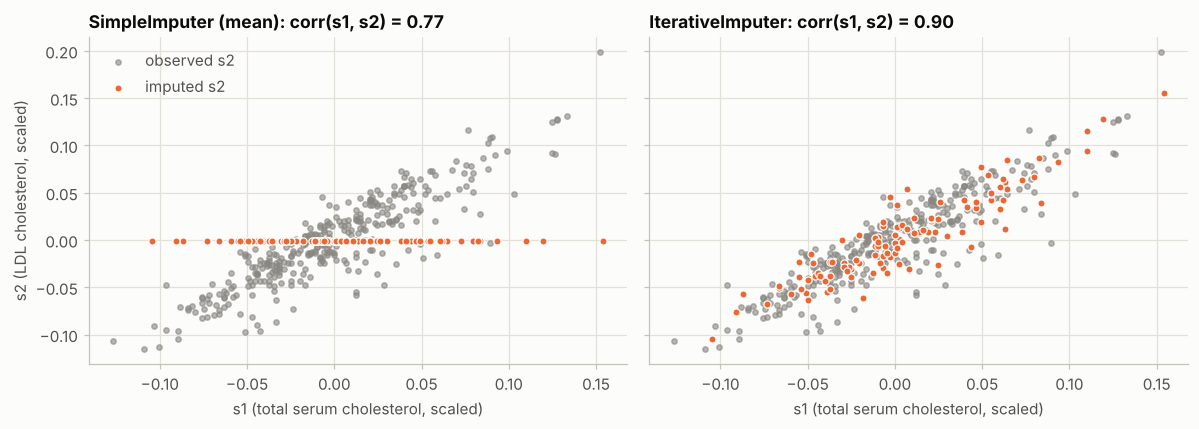

In [10]:
# EXTRA: What mean imputation and iterative imputation do to a strong correlation (s1 vs. s2, r = 0.90)
only_s2 = X_dia.copy()
hide_s2 = np.random.default_rng(1).random(len(only_s2)) < 0.25
only_s2.loc[hide_s2, "s2"] = np.nan
filled = {
    "SimpleImputer (mean)": SimpleImputer(strategy="mean").fit_transform(only_s2),
    "IterativeImputer": IterativeImputer(max_iter=200, random_state=0).fit_transform(only_s2),
}
i1, i2 = X_dia.columns.get_loc("s1"), X_dia.columns.get_loc("s2")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, (name, arr) in zip(axes, filled.items()):
    ax.scatter(arr[~hide_s2, i1], arr[~hide_s2, i2], s=12, color=MUTED, alpha=0.6, label="observed s2")
    ax.scatter(arr[hide_s2, i1], arr[hide_s2, i2], s=22, color=PALETTE[1], edgecolor=SURFACE, linewidth=0.8, label="imputed s2")
    r = np.corrcoef(arr[:, i1], arr[:, i2])[0, 1]
    ax.set(title=f"{name}: corr(s1, s2) = {r:.2f}", xlabel="s1 (total serum cholesterol, scaled)")
axes[0].set_ylabel("s2 (LDL cholesterol, scaled)")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

**Output analysis.**

* **Accuracy on the hidden cells** follows the theory: `IterativeImputer` < `KNNImputer` < mean < median in error, because the diabetes features are correlated and the model-based imputers exploit that, while the column statistics cannot.
* **Downstream performance** (cross-validated R² of a Ridge model, with the imputer *inside* the pipeline so each fold fits it on its own training part) ranks the methods the same way. All of them stay below the complete-data reference: imputation recovers part of the lost information, never all of it.
* **Native missing-value support is not automatically better.** `HistGradientBoostingRegressor` needs no imputer, but on 442 samples it is simply a weaker model than Ridge for this problem.
* **Variance shrinkage:** after mean imputation the standard deviation of `s2` falls by almost exactly the predicted factor $\sqrt{0.8}$.
* **The scatter plots make the difference visible.** Mean imputation stacks every imputed point on one horizontal line and weakens the correlation. Iterative imputation places them along the s1–s2 trend, preserving the structure that a later model will rely on.

---
## 3. Scaling techniques

### Summary

* Features often live on very different scales (age 0–100, income 0–100,000). Algorithms such as k-NN and gradient-descent-based methods are sensitive to this, so scaling ensures no single feature dominates learning.
* Two key terms that are often confused: **standardization** (z-score) gives a feature mean 0 and standard deviation 1; **normalization** rescales values to fall between 0 and 1.
* The right choice depends on the model, on outliers and on the feature distributions. The recipe applies three scalers to `iterative_imputed_df`:
  * `StandardScaler()` — $z = (x - \mu)/\sigma$, values centred on 0 (some become negative); best suited to roughly Gaussian data;
  * `MinMaxScaler()` — rescales to a fixed range, usually $[0, 1]$, preserving the relationships between values;
  * `Normalizer()` — rescales each **sample** to unit norm (L1 or L2); useful for sparse data or when every sample should count equally regardless of magnitude.
* Not every dataset needs scaling: decision trees and random forests work on raw values. k-NN and SVMs are sensitive to feature magnitudes; linear regression converges faster with standardized features.

### Theory: three different operations hiding behind two words

| Transformer | Acts on | Formula | Result |
|---|---|---|---|
| `StandardScaler` | each **column** | $z = \dfrac{x - \mu}{\sigma}$ | mean 0, standard deviation 1 |
| `MinMaxScaler` | each **column** | $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$ | range $[0, 1]$ |
| `RobustScaler` | each **column** | $x' = \dfrac{x - \operatorname{median}}{Q_3 - Q_1}$ | median 0, interquartile range 1 |
| `Normalizer` | each **row** | $\mathbf{x}' = \dfrac{\mathbf{x}}{\lVert \mathbf{x} \rVert_p}$ | every sample has norm 1 |

with $\lVert \mathbf{x} \rVert_1 = \sum_j |x_j|$ and $\lVert \mathbf{x} \rVert_2 = \sqrt{\sum_j x_j^2}$ (`Normalizer` uses L2 by default).

* The word **"normalization"** is used for two unrelated things: min-max scaling of a *feature* (the book's definition) and unit-norm scaling of a *sample* (what `Normalizer` does). `Normalizer` does not bring values into $[0,1]$ feature by feature — it changes each row so that only its *direction* matters, which is what cosine-similarity methods (text classification with TF-IDF, for example) need.
* **Outliers.** $\mu$, $\sigma$, $x_{\min}$ and $x_{\max}$ are all pulled by extreme values, so a single outlier can squash every other value of a feature into a tiny interval. The median and IQR used by `RobustScaler` barely move.
* **No scaler changes the shape** of a distribution: skewed data stay skewed.
* **Trees.** A tree splits on rules like $x_j \le t$. Any strictly increasing transformation $g$ applied to a column keeps the order of its values, so the rule $g(x_j) \le g(t)$ separates exactly the same samples: column-wise scaling does **not change what** decision trees, random forests or gradient-boosted trees learn. (The only exception is floating-point rounding for a new value that lands exactly on a split threshold, examined in the exercise.) The book says scaling would have "a detrimental impact" on them; it is simply unnecessary. (`Normalizer` is different: it mixes the columns of each row, so it *does* change what a tree sees.)
* **Who needs it.** Distance-based models (k-NN, K-means, SVM with RBF kernel), models trained by gradient descent, regularised linear models and PCA.
* As always, the scaler is **fitted on the training data** and only applied to new data.

In [11]:
# BOOK CODE: StandardScaler() (p. 22)
# Load libraries
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data using the iterative imputed DataFrame
scaled_data = scaler.fit_transform(iterative_imputed_df)
scaled_df = pd.DataFrame(scaled_data, columns=iterative_imputed_df.columns)
scaled_df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,0.271931,0.019495,-0.373057,-0.894258,0.188761,0.031844,0.001905,1.683800,-0.780898,-0.003574
1,0.756048,-1.874939,-1.592196,-1.043864,-0.391744,0.085949,1.426871,-0.000534,0.652484,1.429056
2,-0.000939,1.783513,0.231259,1.311954,0.002887,1.021588,0.000854,0.839730,-2.409929,-1.472256
3,0.003022,-1.214477,1.056818,1.458037,-1.411839,1.531340,1.551267,-0.001824,-0.387917,1.053212
4,-1.397054,-0.029802,1.245866,0.559887,0.608499,0.792594,0.451822,-0.001334,0.210478,1.686279
5,-1.828276,0.969036,-1.125549,-2.186891,0.004582,-1.485267,-0.772566,1.831653,0.503915,-1.188904
6,0.878636,1.094467,-0.091017,0.042422,-1.929442,-0.075466,-1.302124,-1.273574,-0.110399,-1.133636
7,-0.000135,0.001649,1.255789,0.639061,0.000428,-0.388327,-0.007723,-0.734020,1.640810,-1.386962
8,-0.225584,0.012729,-0.935710,1.210940,1.323678,0.147955,-1.015275,0.653400,0.040472,-0.476999
9,-0.336923,-0.665377,-0.000435,-1.050256,-0.832163,-0.073336,-0.468360,-0.397536,-0.405072,0.001002


In [12]:
# BOOK CODE: MinMaxScaler() (p. 23)
# Load libraries
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
minmax_scaler = MinMaxScaler()

# Fit and transform the data using the iterative imputed DataFrame
minmax_scaled_data = minmax_scaler.fit_transform(iterative_imputed_df)
minmax_scaled_df = pd.DataFrame(
    minmax_scaled_data, columns=iterative_imputed_df.columns
)
minmax_scaled_df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,0.603506,0.517824,0.380540,0.354639,0.569020,0.555896,0.435006,0.962767,0.402156,0.464988
1,0.721357,0.000000,0.000369,0.313594,0.413077,0.571920,0.833074,0.538604,0.756013,0.918562
2,0.537080,1.000000,0.568987,0.959922,0.519088,0.849027,0.434713,0.750206,0.000000,0.000000
3,0.538045,0.180530,0.826426,1.000000,0.139045,1.000000,0.867825,0.538279,0.499171,0.799569
4,0.197218,0.504349,0.885377,0.753589,0.681776,0.781206,0.560692,0.538402,0.646896,1.000000
5,0.092244,0.777371,0.145886,0.000000,0.519543,0.106575,0.218656,1.000000,0.719336,0.089710
6,0.751199,0.811657,0.468490,0.611621,0.000000,0.524114,0.070723,0.218016,0.567681,0.107208
7,0.537276,0.512946,0.888472,0.775311,0.518428,0.431454,0.432317,0.353891,1.000000,0.027004
8,0.482394,0.515975,0.205085,0.932208,0.873897,0.590284,0.150855,0.703283,0.604927,0.315101
9,0.455290,0.330621,0.496737,0.311840,0.294766,0.524745,0.303637,0.438627,0.494936,0.466437


In [13]:
# BOOK CODE: Normalizer() (p. 24)
# Load libraries
from sklearn.preprocessing import Normalizer

# Initialize the Normalizer
normalizer = Normalizer()

# Fit and transform the data using the iterative imputed DataFrame
normalized_data = normalizer.fit_transform(iterative_imputed_df)
normalized_df = pd.DataFrame(normalized_data, columns=iterative_imputed_df.columns)
normalized_df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,0.339168,0.313579,0.242313,0.200037,0.288183,0.338471,0.295196,0.518860,0.237368,0.278551
1,0.376706,0.051482,0.034682,0.168591,0.204578,0.323683,0.441878,0.273247,0.408426,0.492404
2,0.264336,0.483450,0.300075,0.426192,0.232044,0.423166,0.257371,0.353631,0.008947,0.020717
3,0.243762,0.116607,0.387811,0.407684,0.078213,0.450213,0.392278,0.234729,0.234592,0.370886
4,0.095909,0.248868,0.417511,0.316499,0.274302,0.365945,0.284948,0.237139,0.304609,0.463686
5,0.068115,0.493382,0.128781,0.034471,0.296421,0.126535,0.221071,0.599823,0.463720,0.081177
6,0.460521,0.505281,0.318139,0.354119,0.039204,0.354133,0.145437,0.133292,0.363220,0.090570
7,0.274582,0.281816,0.467778,0.362837,0.240688,0.250170,0.266284,0.175644,0.520792,0.034915
8,0.265283,0.303467,0.143277,0.461427,0.411012,0.345225,0.163323,0.369203,0.341538,0.190645
9,0.321287,0.273524,0.379002,0.223196,0.206875,0.401188,0.293873,0.297140,0.360036,0.347090


**Output analysis.**

* After `StandardScaler` every column is centred on 0 with unit standard deviation, so roughly half the values are negative.
* After `MinMaxScaler` every column runs exactly from 0 to 1: its smallest value maps to 0 and its largest to 1.
* After `Normalizer` the values are all positive (the data are positive) and each **row** has Euclidean length 1. The value in a cell now depends on the *other* values in the same row, which is why this transformer answers a different question from the other two.

The next cell checks all three formulas by hand.

In [14]:
# EXTRA: The three formulas checked by hand on Feature1 and on the first row
f1 = iterative_imputed_df["Feature1"]
z_by_hand = (f1 - f1.mean()) / f1.std(ddof=0)              # population standard deviation, as StandardScaler uses
mm_by_hand = (f1 - f1.min()) / (f1.max() - f1.min())
row0 = iterative_imputed_df.iloc[0].to_numpy()
print("StandardScaler matches (x - mean) / std :", np.allclose(z_by_hand, scaled_df["Feature1"]))
print("MinMaxScaler matches (x - min)/(max - min):", np.allclose(mm_by_hand, minmax_scaled_df["Feature1"]))
print("Normalizer matches x / ||x||_2 (row 0)   :", np.allclose(row0 / np.linalg.norm(row0), normalized_df.iloc[0]))
print("L2 norm of every normalized row          :", np.unique(np.linalg.norm(normalized_df, axis=1).round(12)))
print("learned mean_ / scale_ of Feature1       :", scaler.mean_[0].round(4), "/", scaler.scale_[0].round(4))
print("learned data_min_ / data_max_ of Feature1:", minmax_scaler.data_min_[0].round(4), "/", minmax_scaler.data_max_[0].round(4))

StandardScaler matches (x - mean) / std : True
MinMaxScaler matches (x - min)/(max - min): True
Normalizer matches x / ||x||_2 (row 0)   : True
L2 norm of every normalized row          : [1.]
learned mean_ / scale_ of Feature1       : 52.5612 / 22.9478
learned data_min_ / data_max_ of Feature1: 1.9107 / 96.1778


In [15]:
# EXTRA: (a) What one outlier does to each scaler
from sklearn.preprocessing import RobustScaler

values = np.append(np.random.default_rng(2).normal(50, 5, 99), 500.0).reshape(-1, 1)  # 99 normal values + 1 outlier
rows = []
for sc in [StandardScaler(), MinMaxScaler(), RobustScaler()]:
    t = sc.fit_transform(values).ravel()
    rows.append((type(sc).__name__, t[:-1].min(), t[:-1].max(), t[:-1].max() - t[:-1].min(), t[-1]))
display(pd.DataFrame(rows, columns=["scaler", "inliers: min", "inliers: max", "inliers: spread", "the outlier"])
        .set_index("scaler").round(3))

,inliers: min,inliers: max,inliers: spread,the outlier
scaler,,,,
StandardScaler,-0.371,0.164,0.535,9.895
MinMaxScaler,0.000,0.052,0.052,1.000
RobustScaler,-1.738,1.663,3.401,63.540


In [16]:
# EXTRA: (b) Which models care? k-NN vs. a decision tree on the wine data (features from ~0.1 to ~1,700)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

print("feature ranges in the wine data:", np.round(X_wine.min(axis=0).min(), 2), "to", X_wine.max(axis=0).max())
rows = []
for name, sc in [("no scaling", "passthrough"), ("StandardScaler", StandardScaler()), ("MinMaxScaler", MinMaxScaler()),
                 ("RobustScaler", RobustScaler()), ("Normalizer", Normalizer())]:
    knn_acc = cross_val_score(Pipeline([("scale", sc), ("model", KNeighborsClassifier())]), X_wine, y_wine, cv=cv5).mean()
    tree_acc = cross_val_score(Pipeline([("scale", sc), ("model", DecisionTreeClassifier(random_state=0))]),
                               X_wine, y_wine, cv=cv5).mean()
    rows.append((name, knn_acc, tree_acc))
display(pd.DataFrame(rows, columns=["preprocessing", "k-NN CV accuracy", "decision tree CV accuracy"])
        .set_index("preprocessing").round(3))

feature ranges in the wine data: 0.13 to 1680.0


,k-NN CV accuracy,decision tree CV accuracy
preprocessing,,
no scaling,0.663,0.927
StandardScaler,0.961,0.927
MinMaxScaler,0.972,0.927
RobustScaler,0.955,0.927
Normalizer,0.787,0.933


**Output analysis.**

* **(a) Outliers.** With one value of 500 among values around 50, `MinMaxScaler` squeezes all 99 normal values into a narrow band near 0 and `StandardScaler` compresses them too, because the outlier inflates $\sigma$. `RobustScaler` keeps the normal values spread over a few units (the outlier simply lands far away), which preserves the information that the model actually needs.
* **(b) Who cares about scale.** Without scaling, k-NN is dominated by the one feature measured in the hundreds and thousands (proline) and performs poorly. Any column-wise scaler fixes that. `Normalizer` helps much less, because making each *row* unit length is not what this problem needs.
* **Trees are unaffected:** the decision tree scores *exactly* the same with no scaling, `StandardScaler`, `MinMaxScaler` or `RobustScaler`, confirming that column-wise scaling does not change what a tree learns. Only the row-wise `Normalizer` changes its result.

---
## 4. Encoding categorical variables

### Summary

* Categorical variables hold discrete values (categories, labels, groups), but most algorithms need numbers.
* There are two kinds: **nominal** variables have no order (colour, brand); **ordinal** variables have a natural order (ratings from 1 to 5). The encoding must match the kind.
* The recipe builds a toy dataset of 20 records with three categorical columns (`Department`, `Position`, `Location`) and shows three tools:
  * `OneHotEncoder()` creates one binary column per category (four departments become four 0/1 columns). Many categories produce very large, sparse datasets.
  * `LabelEncoder()` assigns an integer to each category. Simple, but it can suggest an order (or distances) that does not exist, so it must be used with care.
  * `ColumnTransformer()` applies different preprocessing to different columns of a mixed dataset — here, scaling the numeric columns and one-hot encoding the categorical ones in a single step.

### Theory: turning categories into numbers without inventing information

**One-hot encoding.** A feature with categories $\{c_1, \dots, c_k\}$ becomes $k$ indicator columns:

$$\mathbf{e}(x) = \big[\,\mathbb{1}(x = c_1),\ \mathbb{1}(x = c_2),\ \dots,\ \mathbb{1}(x = c_k)\,\big].$$

All categories are equally far apart (every pair differs in exactly two positions), so no order or distance is invented — ideal for **nominal** features.

**The dummy-variable trap.** The $k$ indicators of one feature always sum to 1, so together with the intercept column they are perfectly collinear; an unregularised linear regression then has no unique solution. Remedies: `OneHotEncoder(drop="first")` (keep $k-1$ columns), or a regularised model. Trees and regularised models do not need the drop.

**Integer codes.** `LabelEncoder` maps the sorted unique values to $0, 1, \dots, k-1$ — for strings that means *alphabetical* order.

* scikit-learn designed `LabelEncoder` for the **target** $y$ (a single 1-D column); it is not meant for features and cannot be used inside `ColumnTransformer`.
* For **features**, the right tool is `OrdinalEncoder`, which encodes many columns at once and lets you state the true order of an ordinal variable with `categories=[["Junior", "Senior", "Manager"]]`.
* For a **nominal** feature, integer codes suggest an order and distances that do not exist; tree models tolerate this better than linear or distance-based models.

**Categories not seen during training.** By default `OneHotEncoder` raises an error. `handle_unknown="ignore"` encodes an unseen category as all zeros, and `handle_unknown="infrequent_if_exist"` with `min_frequency` groups rare categories into one column. In production this choice decides whether a new product code crashes the model.

**Many categories.** One-hot encoding a feature with thousands of categories creates thousands of sparse columns. `TargetEncoder` (scikit-learn ≥ 1.3) replaces each category with a shrunken average of the target, using internal cross-fitting so that a row's own target does not leak into its encoding.

**`ColumnTransformer`** applies each transformer to its own list of columns, concatenates the results side by side, and handles the columns not listed according to `remainder` (`"drop"` by default, or `"passthrough"`). Its `get_feature_names_out()` returns the output column names, so they do not need to be written by hand.

In [17]:
# BOOK CODE: Encoding categorical variables -- getting ready (p. 26)
# Load libraries
import numpy as np

# Create sample categorical data with 20 records
np.random.seed(2024)  # for reproducibility
categories = ["A", "B", "C", "D"]
categorical_data = pd.DataFrame(
    {
        "Department": np.random.choice(categories, size=20),
        "Position": np.random.choice(["Junior", "Senior", "Manager"], size=20),
        "Location": np.random.choice(["NY", "SF", "LA", "CHI"], size=20),
    }
)

# Display the DataFrame with categorical values
display(categorical_data)

,Department,Position,Location
0,A,Manager,LA
1,C,Manager,LA
2,A,Junior,NY
3,A,Manager,LA
4,D,Manager,NY
5,A,Senior,LA
6,C,Manager,SF
7,D,Manager,LA
8,B,Junior,LA
9,D,Manager,CHI


In [18]:
# BOOK CODE: OneHotEncoder() (p. 27)
# Load libraries
from sklearn.preprocessing import OneHotEncoder

# Initialize the OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the data
onehot_encoded_data = onehot_encoder.fit_transform(categorical_data)
onehot_encoded_df = pd.DataFrame(
    onehot_encoded_data, columns=onehot_encoder.get_feature_names_out()
)
onehot_encoded_df

,Department_A,Department_B,Department_C,Department_D,Position_Junior,Position_Manager,Position_Senior,Location_CHI,Location_LA,Location_NY,Location_SF
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
9,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [19]:
# BOOK CODE: LabelEncoder() (p. 28)
# Load libraries
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Create a new DataFrame to store label encoded values
label_encoded_df = pd.DataFrame()

# Fit and transform each categorical column
for column in categorical_data.columns:
    label_encoded_df[f"{column}_encoded"] = label_encoder.fit_transform(
        categorical_data[column]
    )
label_encoded_df

,Department_encoded,Position_encoded,Location_encoded
0,0,1,1
1,2,1,1
2,0,0,2
3,0,1,1
4,3,1,2
5,0,2,1
6,2,1,3
7,3,1,1
8,1,0,1
9,3,1,0


In [20]:
# BOOK CODE: ColumnTransformer() -- mixed data (pp. 29-30)
# Load libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Create sample mixed data with 20 records
np.random.seed(2024)  # for reproducibility
mixed_data = pd.DataFrame(
    {
        "Age": np.random.randint(25, 65, size=20),
        "Salary": np.round(np.random.normal(60000, 15000, size=20), 2),
        "Experience": np.random.randint(1, 20, size=20),
        "Department": np.random.choice(["IT", "HR", "Sales", "Finance"], size=20),
        "Position": np.random.choice(["Junior", "Senior", "Manager"], size=20),
    }
)

# Display the DataFrame with mixed data
display(mixed_data)

,Age,Salary,Experience,Department,Position
0,33,59420.36,12,Finance,Manager
1,57,82895.92,17,Sales,Junior
2,25,38165.76,16,Finance,Manager
3,52,38242.36,7,IT,Junior
4,61,55088.65,8,Sales,Manager
5,26,78688.88,9,Sales,Senior
6,60,49585.62,14,Finance,Junior
7,35,47992.58,17,HR,Manager
8,27,54833.02,9,Sales,Senior
9,57,93535.56,14,Sales,Senior


In [21]:
# BOOK CODE: ColumnTransformer() -- transformation (pp. 30-31)
# Initialize the ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["Age", "Salary", "Experience"]),
        ("cat", OneHotEncoder(), ["Department", "Position"]),
    ],
    remainder="passthrough",
)

# Fit and transform the data
transformed_data = column_transformer.fit_transform(mixed_data)

# Get feature names for the transformed columns
numeric_cols = ["Age_scaled", "Salary_scaled", "Experience_scaled"]
categorical_cols = column_transformer.named_transformers_["cat"].get_feature_names_out(
    ["Department", "Position"]
)

# Create the transformed DataFrame
transformed_df = pd.DataFrame(
    transformed_data, columns=numeric_cols + list(categorical_cols)
)
transformed_df

,Age_scaled,Salary_scaled,Experience_scaled,Department_Finance,Department_HR,Department_IT,Department_Sales,Position_Junior,Position_Manager,Position_Senior
0,-1.045349,-0.305043,0.327303,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.727681,1.105091,1.262454,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-1.636358,-1.581768,1.075424,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.358300,-1.577167,-0.607848,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.023186,-0.565241,-0.420818,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,-1.562482,0.852382,-0.233788,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,0.949309,-0.895798,0.701364,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,-0.897596,-0.991489,1.262454,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,-1.488606,-0.580596,-0.233788,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9,0.727681,1.744195,0.701364,0.0,0.0,0.0,1.0,0.0,0.0,1.0


**Output analysis.**

* **One-hot:** 3 features with 4 + 3 + 4 categories become 11 binary columns, named `feature_category` and ordered alphabetically within each feature; every row has exactly one 1 per original feature.
* **Label encoding:** the codes follow *alphabetical* order — for `Position`, Junior = 0, Manager = 1, Senior = 2. That breaks the natural order Junior < Senior < Manager, a concrete case of the "unintended ordinal relationships" the book warns about. The encoder also keeps only the classes of the *last* column it was fitted on, because one `LabelEncoder` was reused for all three columns.
* **`ColumnTransformer`:** three standardized numeric columns plus 4 + 3 one-hot columns give 10 columns. The code builds the names by hand, which works but is fragile: if the column order in the transformer changed, the hand-written names would silently be wrong. The extra cell shows the built-in `get_feature_names_out()`.

In [22]:
# EXTRA: Encoding done right -- ordinal order, unseen categories, the dummy trap, automatic names
from sklearn.preprocessing import OrdinalEncoder

# (1) Ordinal feature with its TRUE order, compared with LabelEncoder's alphabetical codes
ordinal = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
codes = pd.DataFrame({
    "Position": categorical_data["Position"],
    "LabelEncoder (alphabetical)": LabelEncoder().fit_transform(categorical_data["Position"]),
    "OrdinalEncoder (true order)": ordinal.fit_transform(categorical_data[["Position"]]).ravel().astype(int),
}).drop_duplicates().sort_values("OrdinalEncoder (true order)")
display(codes.set_index("Position"))

# (2) A category never seen during training
new_employee = pd.DataFrame({"Department": ["E"], "Position": ["Senior"], "Location": ["NY"]})
try:
    onehot_encoder.transform(new_employee)
except ValueError as err:
    print("default OneHotEncoder ->", str(err).splitlines()[0][:110])
tolerant = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(categorical_data)
print("handle_unknown='ignore' -> Department columns for 'E':",
      tolerant.transform(new_employee)[0, :4], "(all zeros)")

# (3) The dummy-variable trap: one-hot columns of a feature always sum to 1
dept_cols = [c for c in onehot_encoded_df.columns if c.startswith("Department_")]
print("Department one-hot columns sum to 1 in every row:", bool((onehot_encoded_df[dept_cols].sum(axis=1) == 1).all()))
design = np.column_stack([np.ones(len(onehot_encoded_df)), onehot_encoded_df[dept_cols]])
print(f"rank of [intercept | 4 Department columns] = {np.linalg.matrix_rank(design)} (5 columns -> collinear)")
print("with drop='first' ->", OneHotEncoder(drop="first", sparse_output=False).fit(categorical_data[["Department"]])
      .get_feature_names_out().tolist())

# (4) Column names straight from the ColumnTransformer
print("get_feature_names_out():", column_transformer.get_feature_names_out().tolist())

,LabelEncoder (alphabetical),OrdinalEncoder (true order)
Position,,
Junior,0,0
Senior,2,1
Manager,1,2


default OneHotEncoder -> Found unknown categories ['E'] in column 0 during transform
handle_unknown='ignore' -> Department columns for 'E': [0. 0. 0. 0.] (all zeros)
Department one-hot columns sum to 1 in every row: True
rank of [intercept | 4 Department columns] = 4 (5 columns -> collinear)
with drop='first' -> ['Department_B', 'Department_C', 'Department_D']
get_feature_names_out(): ['num__Age', 'num__Salary', 'num__Experience', 'cat__Department_Finance', 'cat__Department_HR', 'cat__Department_IT', 'cat__Department_Sales', 'cat__Position_Junior', 'cat__Position_Manager', 'cat__Position_Senior']


**Output analysis.**

* `OrdinalEncoder` with an explicit category list produces codes that respect the real seniority order, while `LabelEncoder` ranks "Manager" between "Junior" and "Senior".
* An unseen department makes the default encoder fail — exactly what would happen in production on a new product code. `handle_unknown="ignore"` maps it to an all-zero block instead.
* The four department indicators always add up to 1, so with an intercept the design matrix has rank 4 instead of 5: a perfectly collinear set of columns. `drop="first"` removes the redundancy.
* `get_feature_names_out()` produces names such as `num__Age` and `cat__Department_Finance` automatically, in the right order, every time.

---
## 5. Introduction to pipelines in scikit-learn

### Summary

* Real workflows chain many preprocessing steps and a model. `Pipeline()` combines them into one object, which makes code more efficient and less error-prone; the book uses pipelines from here on.
* A pipeline is a **sequence of named steps**, each a transformer or estimator; the last step may optionally be a model such as `LogisticRegression()`. Its advantages:
  * **sequential execution** — steps always run in the same order on training and test data;
  * **code simplification** — many lines become one object;
  * **consistency** — the same transformations at training and prediction time, which minimises the risk of leakage;
  * **easier hyperparameter tuning** — `GridSearchCV` can tune preprocessing and model parameters together;
  * **modularity** — steps are reusable components that can be swapped without rewriting code.
* The recipe splits `transformed_df` into features and a target (the last column), splits into training and test sets **before** any transformation, builds an imputer + scaler pipeline, fits it on the training data and only transforms the test data.
* Splitting first **avoids leakage**, gives a **realistic evaluation**, keeps the transformations **consistent**, is **efficient** (the fitted pipeline handles new data in one call) and **reduces overfitting** to quirks of the whole dataset.
* `set_config(display="diagram")` displays a pipeline as an interactive diagram (the book's Figure 2.13).

### Theory: what a pipeline guarantees — and what it cannot

**Semantics.** For a pipeline $T_1 \rightarrow T_2 \rightarrow \dots \rightarrow T_K \,(\rightarrow E)$:

* `fit(X, y)` calls `fit_transform` on $T_1$, passes the result to $T_2$, and so on, and finally calls `fit` on the estimator $E$ (if there is one);
* `transform(X)` and `predict(X)` apply the **already fitted** steps in the same order and never re-fit them.

A pipeline whose last step is a transformer is itself a transformer (it has `fit_transform` and `transform`, as in the book's recipe); with a model as the last step it is a predictor. Steps are reachable by name (`pipeline.named_steps["scaler"]`) or by position, and `pipeline[:-1]` returns the preprocessing part alone.

**Why the split comes first.** Every learned statistic (the imputer's means, the scaler's $\mu$ and $\sigma$) must come from the training part only; otherwise the test set has influenced the model before it is used to judge it, and the evaluation is optimistic. With a pipeline this happens automatically, also inside each fold of a cross-validation.

**What a pipeline cannot fix: target leakage in the features themselves.** In the book's example the "target" is the last column of `transformed_df`, which is the one-hot indicator `Position_Senior`. The features still contain `Position_Junior` and `Position_Manager`, and the three indicators of one feature always sum to 1, so

$$y = \mathtt{Position\_Senior} = 1 - \mathtt{Position\_Junior} - \mathtt{Position\_Manager}$$

exactly. Any linear model can predict this "target" perfectly from two features. This is harmless for demonstrating the mechanics, but it explains the feature-selection results of the next recipe, and in real projects a feature that is a disguised copy of the target is one of the most common causes of models that look perfect and fail in production.

In [23]:
# BOOK CODE: Creating a pipeline (pp. 33-34)
# Load libraries
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# First, separate features and target (assuming last column is target)
X = transformed_df.iloc[:, :-1]  # all columns except last
y = transformed_df.iloc[:, -1]  # last column

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

# Create a pipeline
pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="mean")),  # handle missing values
        ("scaler", StandardScaler()),  # scale the features
    ]
)

# Fit and transform the training data
X_train_transformed = pipeline.fit_transform(X_train)

# Transform the test data
X_test_transformed = pipeline.transform(X_test)

# Create DataFrames with the transformed data (to preserve column names)
X_train_transformed = pd.DataFrame(
    X_train_transformed, columns=X_train.columns, index=X_train.index
)

X_test_transformed = pd.DataFrame(
    X_test_transformed, columns=X_test.columns, index=X_test.index
)

In [24]:
# BOOK CODE: Visualizing pipelines (pp. 35-36)
# Load libraries
from sklearn import set_config

# Set display configuration
set_config(display="diagram")

# Display the pipeline
pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

**Output analysis.**

* The pipeline was fitted on the 16 training rows only. The 4 test rows were transformed with the training means and standard deviations, so the test set had no influence on the preprocessing.
* The imputer has nothing to fill here (this toy table has no missing values); it is included to show the pattern.
* **The diagram.** When this cell runs in Jupyter or Colab, scikit-learn renders an interactive diagram — the book's Figure 2.13 — with one box per step (`SimpleImputer`, `StandardScaler`) that expands to show its parameters. The copy saved in this repository keeps the cell's plain-text representation of the same object, which lists the same steps and their non-default parameters.

In [25]:
# EXTRA: (a) The book's target is a disguised copy of two features
from sklearn.linear_model import LinearRegression

identity = np.allclose(y, 1 - transformed_df["Position_Junior"] - transformed_df["Position_Manager"])
print("target name:", y.name, "| y == 1 - Position_Junior - Position_Manager for every row:", identity)
leaky_model = LinearRegression().fit(X_train_transformed, y_train)
pred_test = leaky_model.predict(X_test_transformed)
print("held-out targets:", y_test.tolist(), "-> predictions:", (np.round(pred_test, 10) + 0.0).tolist())
print(f"largest absolute error on the held-out rows: {np.abs(pred_test - y_test).max():.1e} | "
      f"training R2: {leaky_model.score(X_train_transformed, y_train):.4f}")
print("its largest coefficients:", pd.Series(leaky_model.coef_, index=X_train.columns).abs()
      .sort_values(ascending=False).head(2).round(3).to_dict())

target name: Position_Senior | y == 1 - Position_Junior - Position_Manager for every row: True
held-out targets: [0.0, 0.0, 0.0, 0.0] -> predictions: [0.0, 0.0, 0.0, 0.0]
largest absolute error on the held-out rows: 6.9e-16 | training R2: 1.0000
its largest coefficients: {'Position_Manager': 0.5, 'Position_Junior': 0.433}


In [26]:
# EXTRA: (b) Preprocessing as a hyperparameter -- let GridSearchCV choose the scaler
from sklearn.model_selection import GridSearchCV

knn_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
search = GridSearchCV(
    knn_pipe,
    param_grid={"scaler": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
                "knn__n_neighbors": [1, 5, 15]},
    cv=cv5,
).fit(X_wine, y_wine)
leaderboard = pd.DataFrame(search.cv_results_)[["param_scaler", "param_knn__n_neighbors", "mean_test_score"]]
leaderboard["param_scaler"] = leaderboard["param_scaler"].map(lambda s: s if isinstance(s, str) else type(s).__name__)
display(leaderboard.sort_values("mean_test_score", ascending=False).head(6).round(4))
print("best:", {k: (v if isinstance(v, (str, int)) else type(v).__name__) for k, v in search.best_params_.items()},
      f"| CV accuracy {search.best_score_:.4f}")

,param_scaler,param_knn__n_neighbors,mean_test_score
9,MinMaxScaler,15,0.9776
5,MinMaxScaler,5,0.9719
8,StandardScaler,15,0.9665
4,StandardScaler,5,0.9608
10,RobustScaler,15,0.9606
2,RobustScaler,1,0.9605


best: {'knn__n_neighbors': 15, 'scaler': 'MinMaxScaler'} | CV accuracy 0.9776


**Output analysis.**

* **(a) Target leakage.** The identity holds for every row. A plain linear regression fits the training rows perfectly ($R^2 = 1$) and reproduces the four held-out "targets" up to rounding error (about $10^{-16}$), using essentially only the two `Position` columns. The held-out targets happen to be all 0, so a test $R^2$ would be undefined — a reminder to look at errors, not only at $R^2$, on tiny test sets. The pipeline did its job — no preprocessing leakage — yet the data themselves contain the answer. Keep this in mind for the feature-selection results below.
* **(b) Tuning the preprocessing.** Because a whole step can be replaced through `set_params`, the scaler becomes a hyperparameter like any other: the grid compares four scalers (including no scaling, `"passthrough"`) and three neighbourhood sizes, with every preprocessing step re-fitted inside every fold. Unscaled k-NN sits at the bottom of the full table, consistent with recipe 3. This is the "easier hyperparameter tuning" advantage the book lists.

---
## 6. Feature engineering

### Summary

* Feature engineering covers two activities: **feature extraction** (creating new variables, such as total spending from price and quantity) and **feature selection** (keeping the informative variables and discarding the rest). Done well, it gives simpler models that generalise better.
* The book groups the methods into **filter** methods (statistical properties of each feature), **wrapper** methods (fit models on feature subsets and compare them) and **hybrid** methods (a mix of both).
* Creating features, applied to `X_train_transformed`:
  * `PolynomialFeatures(degree=2)` adds squares and pairwise products (interactions);
  * `KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="uniform")` turns continuous values into bins — `uniform` (equal widths), `quantile` (equal counts) or `kmeans` (clusters).
* Selecting features (the best model performs well with the fewest features):
  * `RFE` (recursive feature elimination) repeatedly fits a model and prunes the least important feature; `RFECV` adds cross-validation;
  * `SelectFromModel` keeps the features whose importance (coefficients or feature importances) exceeds a threshold, here the mean.

### Theory: creating features, and choosing among them

**Polynomial features.** With $n$ input features and degree $d$, `PolynomialFeatures` produces every monomial of total degree at most $d$, including the constant:

$$\#\text{columns} = \binom{n + d}{d}, \qquad n = 9,\ d = 2:\ \binom{11}{2} = 55 = 1 + 9 + \underbrace{9}_{\text{squares}} + \underbrace{36}_{\text{interactions}}.$$

The count explodes with $d$, so polynomial features are usually followed by regularisation or selection. They let a *linear* model fit curves: $y = \beta_0 + \beta_1 x + \beta_2 x^2$ is still linear in the coefficients. Two caveats for one-hot inputs: for a 0/1 column $x^2 = x$, and the product of two indicators of the same feature is always 0 — such columns add nothing (verified below).

**Binning.** `KBinsDiscretizer` with $k$ bins:

* `uniform` — equal widths $(x_{\max} - x_{\min})/k$, so skewed data leave most bins almost empty;
* `quantile` — edges at the quantiles, so every bin holds about $n/k$ samples;
* `kmeans` — runs 1-D K-means; the edges lie halfway between neighbouring cluster centres.

Binning lets linear models capture thresholds and non-linear effects, at the cost of information within each bin.

**Feature-selection families** (the usual names for the book's three groups):

| Family | Idea | scikit-learn |
|---|---|---|
| Filter | score each feature on its own (variance, correlation, F-test, mutual information) | `VarianceThreshold`, `SelectKBest` |
| Wrapper | search over subsets by refitting a model | `RFE`, `RFECV`, `SequentialFeatureSelector` |
| Embedded | selection happens inside training (L1 penalties, tree importances) | `SelectFromModel` with `Lasso` or a forest |

**RFE** (Guyon et al., 2002):

1. fit the estimator on the current feature set;
2. rank the features by importance — $|\beta_j|$ for linear models, `feature_importances_` for trees;
3. remove the `step` least important ones;
4. repeat until `n_features_to_select` remain.

`ranking_` is 1 for the selected features and counts up in reverse order of elimination. Because $|\beta_j|$ is compared across features, the features must be on comparable scales — the book's input is standardised, as it should be. `RFECV` chooses the number of features by cross-validation.

**`SelectFromModel`** fits once and keeps every feature whose importance reaches the threshold (`"mean"`, `"median"`, a number, or `"1.25*mean"`).

In [27]:
# BOOK CODE: PolynomialFeatures() (pp. 37-38)
# Load libraries
from sklearn.preprocessing import PolynomialFeatures

# Initialize the PolynomialFeatures
poly = PolynomialFeatures(degree=2)

# Fit and transform the X_train_transformed data
poly_features = poly.fit_transform(X_train_transformed)
poly_features_df = pd.DataFrame(
    poly_features, columns=poly.get_feature_names_out(X_train_transformed.columns)
)
poly_features_df

,1,Age_scaled,Salary_scaled,Experience_scaled,Department_Finance,Department_HR,Department_IT,Department_Sales,Position_Junior,Position_Manager,Age_scaled^2,Age_scaled Salary_scaled,Age_scaled Experience_scaled,Age_scaled Department_Finance,Age_scaled Department_HR,Age_scaled Department_IT,Age_scaled Department_Sales,Age_scaled Position_Junior,Age_scaled Position_Manager,Salary_scaled^2,Salary_scaled Experience_scaled,Salary_scaled Department_Finance,Salary_scaled Department_HR,Salary_scaled Department_IT,Salary_scaled Department_Sales,Salary_scaled Position_Junior,Salary_scaled Position_Manager,Experience_scaled^2,Experience_scaled Department_Finance,Experience_scaled Department_HR,Experience_scaled Department_IT,Experience_scaled Department_Sales,Experience_scaled Position_Junior,Experience_scaled Position_Manager,Department_Finance^2,Department_Finance Department_HR,Department_Finance Department_IT,Department_Finance Department_Sales,Department_Finance Position_Junior,Department_Finance Position_Manager,Department_HR^2,Department_HR Department_IT,Department_HR Department_Sales,Department_HR Position_Junior,Department_HR Position_Manager,Department_IT^2,Department_IT Department_Sales,Department_IT Position_Junior,Department_IT Position_Manager,Department_Sales^2,Department_Sales Position_Junior,Department_Sales Position_Manager,Position_Junior^2,Position_Junior Position_Manager,Position_Manager^2
0,1.0,0.834298,-0.867451,-1.559779,-0.577350,-0.480384,2.081666,-0.774597,-0.577350,-1.0,0.696053,-0.723712,-1.301320,-0.481682,-0.400784,1.736729,-0.646244,-0.481682,-0.834298,0.752471,1.353032,0.500823,0.416710,-1.805743,0.671925,0.500823,0.867451,2.432911,0.900539,0.749294,-3.246939,1.208200,0.900539,1.559779,0.333333,0.27735,-1.20185,0.447214,0.333333,0.577350,0.230769,-1.000000,0.372104,0.277350,0.480384,4.333333,-1.612452,-1.201850,-2.081666,0.600000,0.447214,0.774597,0.333333,0.577350,1.0
1,1.0,-0.689202,1.282818,-0.150946,-0.577350,2.081666,-0.480384,-0.774597,-0.577350,1.0,0.475000,-0.884122,0.104033,0.397911,-1.434689,0.331082,0.533854,0.397911,-0.689202,1.645623,-0.193637,-0.740636,2.670400,-0.616246,-0.993667,-0.740636,1.282818,0.022785,0.087149,-0.314220,0.072512,0.116923,0.087149,-0.150946,0.333333,-1.20185,0.27735,0.447214,0.333333,-0.577350,4.333333,-1.000000,-1.612452,-1.201850,2.081666,0.230769,0.372104,0.277350,-0.480384,0.600000,0.447214,-0.774597,0.333333,-0.577350,1.0
2,1.0,0.544107,-1.173357,-1.761041,-0.577350,-0.480384,2.081666,-0.774597,-0.577350,1.0,0.296053,-0.638432,-0.958195,-0.314140,-0.261381,1.132649,-0.421464,-0.314140,0.544107,1.376766,2.066329,0.677438,0.563662,-2.442537,0.908878,0.677438,-1.173357,3.101266,1.016738,0.845977,-3.665899,1.364097,1.016738,-1.761041,0.333333,0.27735,-1.20185,0.447214,0.333333,-0.577350,0.230769,-1.000000,0.372104,0.277350,-0.480384,4.333333,-1.612452,-1.201850,2.081666,0.600000,0.447214,-0.774597,0.333333,-0.577350,1.0
3,1.0,-1.342131,0.821525,-0.150946,-0.577350,-0.480384,-0.480384,1.290994,-0.577350,-1.0,1.801316,-1.102594,0.202590,0.774880,0.644739,0.644739,-1.732684,0.774880,1.342131,0.674903,-0.124006,-0.474307,-0.394648,-0.394648,1.060584,-0.474307,-0.821525,0.022785,0.087149,0.072512,0.072512,-0.194871,0.087149,0.150946,0.333333,0.27735,0.27735,-0.745356,0.333333,0.577350,0.230769,0.230769,-0.620174,0.277350,0.480384,0.230769,-0.620174,0.277350,0.480384,1.666667,-0.745356,-1.290994,0.333333,0.577350,1.0
4,1.0,1.414679,0.611115,0.654101,-0.577350,-0.480384,-0.480384,1.290994,-0.577350,1.0,2.001316,0.864531,0.925343,-0.816765,-0.679590,-0.679590,1.826342,-0.816765,1.414679,0.373461,0.399731,-0.352827,-0.293570,-0.293570,0.788946,-0.352827,0.611115,0.427848,-0.377645,-0.314220,-0.314220,0.844441,-0.377645,0.654101,0.333333,0.27735,0.27735,-0.745356,0.333333,-0.577350,0.230769,0.230769,-0.620174,0.277350,-0.480384,0.230769,-0.620174,0.277350,-0.480384,1.666667,-0.745356,1.290994,0.333333,-0.577350,1.0
5,1.0,-1.414679,-1.479801,1.257887,1.732051,-0.480384,-0.480384,-

In [28]:
# BOOK CODE: KBinsDiscretizer() (pp. 38-39)
# Load libraries
from sklearn.preprocessing import KBinsDiscretizer

# Initialize the KBinsDiscretizer
kbins = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="uniform")

# Fit and transform the X_train_transformed data
binned_data = kbins.fit_transform(X_train_transformed)
binned_df = pd.DataFrame(binned_data, columns=X_train_transformed.columns)
binned_df

,Age_scaled,Salary_scaled,Experience_scaled,Department_Finance,Department_HR,Department_IT,Department_Sales,Position_Junior,Position_Manager
0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
1,0.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,2.0
2,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
3,0.0,2.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0
4,2.0,1.0,2.0,0.0,0.0,0.0,2.0,0.0,2.0
5,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0
6,2.0,1.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0
7,2.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0
8,2.0,2.0,2.0,0.0,0.0,0.0,2.0,2.0,0.0
9,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0


In [29]:
# BOOK CODE: Recursive feature elimination with RFE (pp. 39-40)
# Load libraries
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Initialize the RFE
rfe = RFE(estimator=LinearRegression(), n_features_to_select=1)

# Fit the RFE to the X_train_transformed and y_train data
rfe.fit(X_train_transformed, y_train)

# Get the ranking of features
rfe.ranking_

# Output: array([5, 4, 8, 6, 9, 3, 7, 2, 1])

array([3, 9, 8, 6, 5, 4, 7, 2, 1])

In [30]:
# BOOK CODE: SelectFromModel() (pp. 40-41)
# Load libraries
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression

# Initialize SelectFromModel with LinearRegression
selector = SelectFromModel(
    estimator=LinearRegression(),
    prefit=False,
    threshold="mean",  # Use mean of feature importances as threshold
)

# Fit the selector
selector.fit(X_train_transformed, y_train)

# Get selected features
selected_features_mask = selector.get_support()

# Get feature names that were selected
selected_features = X_train_transformed.columns[selected_features_mask].tolist()

# Print feature importance scores and selection status
feature_importance = pd.DataFrame(
    {
        "Feature": X_train_transformed.columns,
        "Importance": selector.estimator_.coef_,
        "Selected": selected_features_mask,
    }
)
feature_importance.sort_values("Importance", key=abs, ascending=False)

,Feature,Importance,Selected
8,Position_Manager,-5.000000e-01,True
7,Position_Junior,-4.330127e-01,True
6,Department_Sales,-9.116147e-16,False
3,Department_Finance,-8.700954e-16,False
5,Department_IT,-7.202125e-16,False
4,Department_HR,-5.139679e-16,False
2,Experience_scaled,-1.995702e-16,False
0,Age_scaled,-1.221550e-16,False
1,Salary_scaled,0.000000e+00,False


**Output analysis.**

* **`PolynomialFeatures`** turns 9 columns into 55 — exactly $\binom{11}{2}$ — for only 16 training rows, so a model on these features would have far more columns than samples.
* **`KBinsDiscretizer`** with uniform bins maps each standardised column to 0, 1 or 2. The originally binary columns can only land in the two outer bins.
* **`RFE` ranking.** The last two eliminated features — ranks 1 and 2, `Position_Manager` and `Position_Junior` — are the same as in the book. Ranks 3 to 9 differ from the book's array. That is expected: once the two `Position` columns are in the model they explain the target *exactly* (recipe 5), so every other coefficient is zero up to floating-point round-off (about $10^{-16}$). RFE then eliminates features in an order decided by rounding noise, which changes with the machine, the BLAS library and the library version.
* **`SelectFromModel`** tells the same story: `Position_Manager` and `Position_Junior` carry all the weight and are the only features above the mean threshold, while every other coefficient is numerically zero.

The extra cells below rerun the selectors on data with a *known* answer, to show what these tools do when the target is not leaked.

In [31]:
# EXTRA: Polynomial features on 0/1 columns add nothing new
X_dummies = X[["Position_Junior", "Position_Manager"]]                 # the unscaled 0/1 indicators
poly_dummies = pd.DataFrame(PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_dummies),
                            columns=PolynomialFeatures(degree=2, include_bias=False).fit(X_dummies).get_feature_names_out())
print("columns:", poly_dummies.columns.tolist())
print("Position_Junior^2 equals Position_Junior :", poly_dummies["Position_Junior^2"].equals(poly_dummies["Position_Junior"]))
print("Position_Junior * Position_Manager is always 0:", bool((poly_dummies["Position_Junior Position_Manager"] == 0).all()))

columns: ['Position_Junior', 'Position_Manager', 'Position_Junior^2', 'Position_Junior Position_Manager', 'Position_Manager^2']
Position_Junior^2 equals Position_Junior : True
Position_Junior * Position_Manager is always 0: True


5-fold CV R2: straight line = 0.594 | degree-2 polynomial features = 0.937


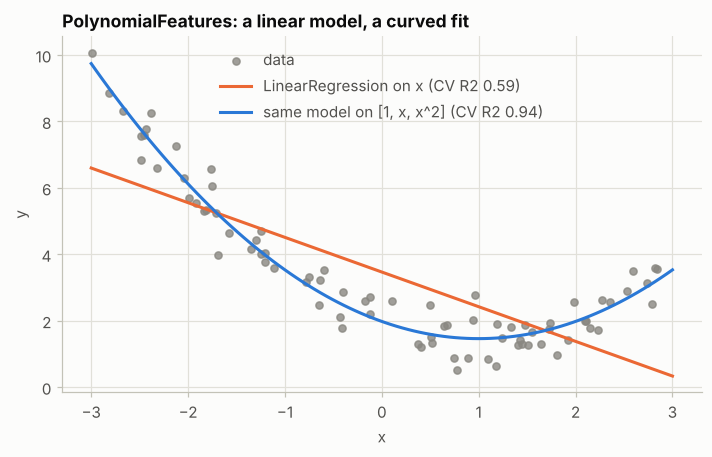

In [32]:
# EXTRA: Polynomial features let a linear model fit a curve
rng = np.random.default_rng(3)
x_curve = rng.uniform(-3, 3, 80)
y_curve = 0.5 * x_curve ** 2 - x_curve + 2 + rng.normal(0, 0.5, 80)        # quadratic ground truth
linear_fit = LinearRegression()
quad_fit = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
cv_lin = cross_val_score(linear_fit, x_curve.reshape(-1, 1), y_curve, cv=5, scoring="r2").mean()
cv_quad = cross_val_score(quad_fit, x_curve.reshape(-1, 1), y_curve, cv=5, scoring="r2").mean()
print(f"5-fold CV R2: straight line = {cv_lin:.3f} | degree-2 polynomial features = {cv_quad:.3f}")

grid_c = np.linspace(-3, 3, 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(x_curve, y_curve, s=22, color=MUTED, alpha=0.8, label="data")
ax.plot(grid_c, linear_fit.fit(x_curve.reshape(-1, 1), y_curve).predict(grid_c), color=PALETTE[1], label=f"LinearRegression on x (CV R2 {cv_lin:.2f})")
ax.plot(grid_c, quad_fit.fit(x_curve.reshape(-1, 1), y_curve).predict(grid_c), color=PALETTE[0], label=f"same model on [1, x, x^2] (CV R2 {cv_quad:.2f})")
ax.set(xlabel="x", ylabel="y", title="PolynomialFeatures: a linear model, a curved fit")
ax.legend(loc="upper center")
plt.show()

In [33]:
# EXTRA: The three binning strategies on skewed data
skewed = np.random.default_rng(4).lognormal(mean=0, sigma=0.8, size=500).reshape(-1, 1)
rows = []
for strategy in ["uniform", "quantile", "kmeans"]:
    kb = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy=strategy).fit(skewed)
    counts = np.bincount(kb.transform(skewed).ravel().astype(int), minlength=4)
    rows.append((strategy, np.round(kb.bin_edges_[0], 2).tolist(), counts.tolist()))
display(pd.DataFrame(rows, columns=["strategy", "bin edges", "samples per bin"]).set_index("strategy"))

,bin edges,samples per bin
strategy,,
uniform,"[0.08, 2.42, 4.75, 7.09, 9.43]","[431, 57, 10, 2]"
quantile,"[0.08, 0.58, 0.99, 1.78, 9.43]","[125, 125, 125, 125]"
kmeans,"[0.08, 1.38, 3.0, 5.42, 9.43]","[331, 127, 34, 8]"


In [34]:
# EXTRA: Feature selection checked against a known ground truth
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.linear_model import Lasso

X_sel, y_sel, true_coef = make_regression(n_samples=200, n_features=12, n_informative=4, noise=10,
                                          coef=True, random_state=0)
truth = np.flatnonzero(true_coef)
methods = {
    "ground truth (informative features)": truth,
    "RFE(LinearRegression, 4 features)": np.flatnonzero(RFE(LinearRegression(), n_features_to_select=4).fit(X_sel, y_sel).support_),
    "RFECV(LinearRegression)": np.flatnonzero(RFECV(LinearRegression(), cv=5).fit(X_sel, y_sel).support_),
    "SelectFromModel(Lasso(alpha=1))": np.flatnonzero(SelectFromModel(Lasso(alpha=1.0)).fit(X_sel, y_sel).get_support()),
    "SelectFromModel(RandomForest)": np.flatnonzero(SelectFromModel(
        RandomForestRegressor(n_estimators=200, random_state=0)).fit(X_sel, y_sel).get_support()),
}
display(pd.DataFrame({
    "selected feature indices": [list(v) for v in methods.values()],
    "true positives": [len(set(v) & set(truth)) for v in methods.values()],
    "false positives": [len(set(v) - set(truth)) for v in methods.values()],
}, index=list(methods)))

,selected feature indices,true positives,false positives
ground truth (informative features),"[2, 8, 10, 11]",4,0
"RFE(LinearRegression, 4 features)","[2, 8, 10, 11]",4,0
RFECV(LinearRegression),"[2, 8, 10, 11]",4,0
SelectFromModel(Lasso(alpha=1)),"[1, 2, 8, 10, 11]",4,1
SelectFromModel(RandomForest),"[2, 8, 10]",3,0


**Output analysis.**

* For 0/1 columns, squaring returns the same column and the product of two indicators of the same feature is identically zero. Polynomial expansion of one-hot data mainly adds redundant columns, so it is best applied to genuinely numeric features.
* On a curved relationship, adding $x^2$ lifts the cross-validated $R^2$ of the *same* linear regression dramatically: the model stays linear in its coefficients but no longer in $x$.
* **Binning skewed data:** `uniform` puts most samples in the first bin and leaves the last nearly empty; `quantile` gives four equally full bins; `kmeans` lands in between, following where the data actually cluster.
* **Selection with a known answer:**
  * RFE and RFECV recover exactly the four informative features. RFECV also finds the right *number* by itself.
  * Lasso keeps all four plus one false positive.
  * The random forest's importance threshold (the mean) misses a weak informative feature.

  Different selectors make different mistakes, so the choice should be validated rather than assumed.

---
## 7. Practical exercise on data preprocessing (California Housing)

### Summary

The chapter ends with an exercise: build a comprehensive pipeline for the **California Housing** dataset that ships with scikit-learn's dataset loaders. The steps are:

1. load the dataset;
2. split the data;
3. create a pipeline with at least three steps, the last being a model that predicts the target;
4. fit the pipeline;
5. evaluate it on the test data.

The book's official repository provides a solution: median imputation, standard scaling and a `RandomForestRegressor`, scored with `score()` on a 20 % test split.

### Theory: the dataset and how to judge a regression model

**The data** (from the dataset's own description in scikit-learn):

* 20,640 census **block groups** from the 1990 U.S. census;
* **8** numeric features: median income, median house age, average rooms and bedrooms per household, population, average occupancy, latitude and longitude;
* the **target** is the *median house value* of the block group, in units of \$100,000;
* no missing values.

*A precision:* the book describes 9 features and a target of "average home price per 100,000 homes". The ninth column is the target itself, and the target is a median value expressed in hundreds of thousands of dollars. The target is also **capped**: 965 districts sit exactly at the maximum of 5.00001, a censoring that every model has to live with.

**Metrics.** A regressor's `score()` is $R^2 = 1 - SS_{\text{res}}/SS_{\text{tot}}$ (Chapter 1). Two error measures in the units of the target are easier to communicate:

$$\text{RMSE} = \sqrt{\tfrac{1}{n}\sum_i (y_i - \hat y_i)^2}, \qquad \text{MAE} = \tfrac{1}{n}\sum_i |y_i - \hat y_i|.$$

RMSE punishes large errors more; MAE is the typical error in \$100,000 units. A model should also be compared with a trivial **baseline** — predicting the training mean — to show that it learned anything at all.

**The pipeline's steps in context.** The data contain no missing values, so the imputer has nothing to fill. Random forests are insensitive to column-wise scaling (recipe 3), so the scaler does not change what the model learns either. Both steps are harmless and make the pipeline ready for messier data, which is the point of the exercise; the extra cells verify both statements.

In [35]:
# BOOK CODE: Comprehensive pipeline -- exercise solution from the book's official repository (p. 42)
# Load libraries
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load the California Housing dataset
california_data = fetch_california_housing()
X, y = california_data.data, california_data.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

# Create a comprehensive pipeline
comprehensive_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor()),
    ]
)

# Fit the pipeline
comprehensive_pipeline.fit(X_train, y_train)

# Evaluate the pipeline
score = comprehensive_pipeline.score(X_test, y_test)
score

0.8025722856848019

**Output analysis.** The pipeline explains about 80 % of the variance of house values on the 4,128 held-out districts ($R^2 \approx 0.80$). The random forest is not given a `random_state`, so the exact score varies slightly from run to run (it is reproducible here only because of the global seed set in the setup cell). The next cells put the number in context.

In [36]:
# EXTRA: The same split, more metrics, and simple baselines for comparison
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("missing values in the California data:", int(np.isnan(X).sum()), "| capped targets:", int((y == y.max()).sum()))
models = {
    "baseline: always predict the training mean": DummyRegressor(strategy="mean"),
    "linear regression (imputer + scaler)": Pipeline([("imputer", SimpleImputer(strategy="median")),
                                                      ("scaler", StandardScaler()), ("model", LinearRegression())]),
    "random forest (book solution)": comprehensive_pipeline,
    "HistGradientBoosting (no preprocessing)": HistGradientBoostingRegressor(random_state=0),
}
rows = []
for name, model in models.items():
    if model is not comprehensive_pipeline:                      # the book's pipeline is already fitted
        model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append((name, r2_score(y_test, pred), np.sqrt(mean_squared_error(y_test, pred)),
                 mean_absolute_error(y_test, pred)))
display(pd.DataFrame(rows, columns=["model", "R2", "RMSE ($100k)", "MAE ($100k)"]).set_index("model").round(3))

missing values in the California data: 0 | capped targets: 965


,R2,RMSE ($100k),MAE ($100k)
model,,,
baseline: always predict the training mean,-0.000,1.170,0.921
linear regression (imputer + scaler),0.599,0.741,0.535
random forest (book solution),0.803,0.520,0.334
HistGradientBoosting (no preprocessing),0.835,0.475,0.312


all 50 trees have identical structure (same split features, same shape): True
R2 without preprocessing: 0.8019 | with imputer + scaler: 0.8021
test districts predicted differently (by more than 1e-9): 1404 of 4128 (largest difference 0.168)


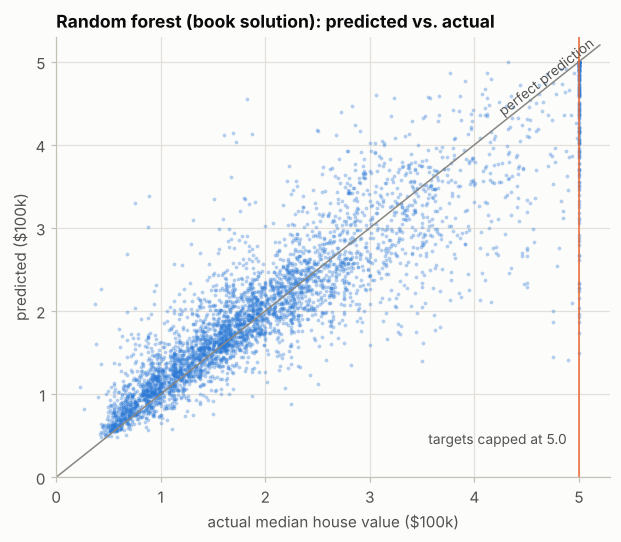

In [37]:
# EXTRA: Do the imputer and the scaler change the random forest? (same seed, with and without them)
forest_raw = RandomForestRegressor(n_estimators=50, random_state=0).fit(X_train, y_train)
forest_pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                       ("model", RandomForestRegressor(n_estimators=50, random_state=0))]).fit(X_train, y_train)
same_trees = all(np.array_equal(a.tree_.feature, b.tree_.feature) and np.array_equal(a.tree_.children_left, b.tree_.children_left)
                 for a, b in zip(forest_raw.estimators_, forest_pre.named_steps["model"].estimators_))
p_raw, p_pre = forest_raw.predict(X_test), forest_pre.predict(X_test)
print("all 50 trees have identical structure (same split features, same shape):", same_trees)
print(f"R2 without preprocessing: {r2_score(y_test, p_raw):.4f} | with imputer + scaler: {r2_score(y_test, p_pre):.4f}")
gap = np.abs(p_raw - p_pre)
print(f"test districts predicted differently (by more than 1e-9): {int((gap > 1e-9).sum())} of {len(gap)} "
      f"(largest difference {gap.max():.3f})")

pred_book = comprehensive_pipeline.predict(X_test)
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.scatter(y_test, pred_book, s=6, color=PALETTE[0], alpha=0.35, linewidth=0)
ax.plot([0, 5.2], [0, 5.2], color=MUTED, linewidth=1)
ax.annotate("perfect prediction", (4.2, 4.35), color=INK_SOFT, fontsize=9, rotation=38)
ax.axvline(y.max(), color=PALETTE[1], linewidth=1)
ax.annotate("targets capped at 5.0", (y.max(), 0.4), xytext=(-8, 0), textcoords="offset points", ha="right",
            color=INK_SOFT, fontsize=9)
ax.set(xlabel="actual median house value ($100k)", ylabel="predicted ($100k)", xlim=(0, 5.3), ylim=(0, 5.3),
       title="Random forest (book solution): predicted vs. actual")
plt.show()

**Output analysis.**

* **Context for the score:**
  * The mean baseline has $R^2 \approx 0$ by construction.
  * Linear regression reaches only about 0.6, because house prices depend non-linearly on location and income.
  * The random forest's 0.80 corresponds to a typical error (MAE) of roughly \$33,000.
  * A gradient-boosted model with no preprocessing at all does even better ($R^2 \approx 0.84$), in a fraction of the time.
* **Imputer and scaler change nothing the forest learns.** The data have no missing values, and with the same seed the forest with and without the imputer + scaler grows exactly the same 50 trees, so the scores agree to three decimals. Predictions still differ slightly for many districts, and the reason is exact ties. A split threshold sits halfway between two neighbouring training values — a node holding house ages 4 and 6 splits at exactly 5 — so a new district aged exactly 5 is routed by the last bit of floating-point rounding, which differs between raw and standardised numbers. Each tree meets such a tie for only a handful of districts, but a forest averages 50 trees, so a large share of districts hits at least one tie somewhere; each is moved by a small amount (at most 0.17 here). Scaling only moves exact ties; it changes nothing the forest learns, as recipe 3 predicted. The steps are still good practice, because a deployed pipeline will meet missing values sooner or later.
* **The plot** shows the forest following the diagonal and the vertical wall at the capped value 5.0, where the true values are censored and every model underestimates.

---
## Decision guide: choosing a preprocessing step

The book closes the chapter with a decision diagram (Figure 2.17) for choosing transformations based on the characteristics of the data. The same guidance as a table:

| Situation in the data | Step | scikit-learn tool |
|---|---|---|
| Few numeric values missing at random | Mean or median imputation | `SimpleImputer` |
| Missing values in a categorical column | Most frequent value or a constant | `SimpleImputer(strategy="most_frequent")` |
| More missing values, correlated numeric features | Model-based imputation | `KNNImputer`, `IterativeImputer` |
| The fact that a value is missing is informative | Add missingness indicators | `add_indicator=True`, `MissingIndicator` |
| Distance-based, gradient-based or regularised model | Standardize | `StandardScaler` |
| A bounded range is required, no outliers | Min-max scaling | `MinMaxScaler` |
| Outliers present | Robust scaling, capping or a robust loss | `RobustScaler`, `HuberRegressor` |
| Only the direction of each sample matters | Unit-norm rows | `Normalizer` |
| Tree-based model | Usually no scaling needed | — |
| Nominal categories | One-hot encoding | `OneHotEncoder(handle_unknown="ignore")` |
| Ordinal categories | Ordered integer codes | `OrdinalEncoder(categories=...)` |
| Very many categories | Target or frequency-based encoding | `TargetEncoder`, `OneHotEncoder(min_frequency=...)` |
| Numeric and categorical columns together | Per-column processing | `ColumnTransformer` |
| Curved relationships for a linear model | Polynomial or spline features | `PolynomialFeatures`, `SplineTransformer` |
| Threshold effects | Binning | `KBinsDiscretizer` |
| Many irrelevant features | Feature selection | `RFE`, `RFECV`, `SelectFromModel` |
| Always | Fit everything inside a pipeline, after the split | `Pipeline`, `make_pipeline` |

---
## Chapter summary and key takeaways

| Recipe | Main tools | Key idea |
|---|---|---|
| Impact of raw data | — | Label noise, irrelevant features and outliers each cost accuracy in measurable ways |
| Missing data | `SimpleImputer`, `KNNImputer`, `IterativeImputer` | Choose by mechanism and correlation; fit imputers on training data only |
| Scaling | `StandardScaler`, `MinMaxScaler`, `Normalizer`, `RobustScaler` | Column-wise scaling matters for distance and gradient methods, not for trees |
| Encoding | `OneHotEncoder`, `OrdinalEncoder`, `LabelEncoder`, `ColumnTransformer` | Match the encoding to nominal vs. ordinal; plan for unseen categories |
| Pipelines | `Pipeline`, `set_config(display="diagram")` | Split first, then fit every step on training data; pipelines cannot detect a leaked target |
| Feature engineering | `PolynomialFeatures`, `KBinsDiscretizer`, `RFE`, `SelectFromModel` | Create features thoughtfully, then validate any selection against held-out data |
| Practical exercise | `fetch_california_housing`, `RandomForestRegressor` | Judge a model with several metrics and against baselines |

**Key takeaways**

1. Data quality sets the ceiling for model quality: noisy labels and irrelevant features cost accuracy before any algorithm is chosen.
2. Imputation is a modelling decision. Mean imputation is fast but shrinks variance; model-based imputers pay off when features are correlated.
3. "Standardization", "min-max scaling" and "normalization" are different operations; pick by model type and by the presence of outliers.
4. Encode nominal features with one-hot, ordinal features with an explicit order, and always decide what happens with unseen categories.
5. Every learned preprocessing statistic belongs to the training data: split first and put the steps in a pipeline.
6. Feature selection can only be as honest as the data: a feature that leaks the target will always look like the best feature.

**Book (scikit-learn 1.5) vs. the version used here — notes from the reproduction**

* All listings run unchanged on scikit-learn 1.9.1. The printed values that the book quotes are reproduced (the imputed mean 52.558605, and the two features ranked first by RFE); RFE ranks 3–9 differ because they are decided by floating-point round-off (recipe 6).
* Small precisions to the chapter text:
  * `KNNImputer` averages the neighbours' values instead of taking a "majority label".
  * `IterativeImputer` regresses on all other features (with their current imputations) and, like `KNNImputer`, needs numeric input.
  * The "> 5 %" guideline presumably means "< 5 %".
  * Column-wise scaling is unnecessary rather than detrimental for trees.
  * `LabelEncoder` is meant for targets, so `OrdinalEncoder` is the tool for features.
  * The pipeline example's target is determined by two of its features.
  * The California target is a median value in \$100,000 units, with 8 features plus the target.
  * The closing note means "Chapter 2 covered feature engineering; Chapter 3 covers dimensionality reduction".

## References

1. Sukup, J. (2025). *scikit-learn Cookbook* (3rd ed.). Packt Publishing. Code repository: <https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition>
2. Rubin, D. B. (1976). Inference and missing data. *Biometrika, 63*(3), 581–592.
3. Troyanskaya, O., Cantor, M., Sherlock, G., Brown, P., Hastie, T., Tibshirani, R., Botstein, D., & Altman, R. B. (2001). Missing value estimation methods for DNA microarrays. *Bioinformatics, 17*(6), 520–525.
4. van Buuren, S., & Groothuis-Oudshoorn, K. (2011). mice: Multivariate Imputation by Chained Equations in R. *Journal of Statistical Software, 45*(3), 1–67.
5. Guyon, I., Weston, J., Barnhill, S., & Vapnik, V. (2002). Gene selection for cancer classification using support vector machines. *Machine Learning, 46*(1–3), 389–422.
6. Huber, P. J. (1964). Robust estimation of a location parameter. *The Annals of Mathematical Statistics, 35*(1), 73–101.
7. Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. *Statistics & Probability Letters, 33*(3), 291–297.
8. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
9. scikit-learn documentation: [Imputation of missing values](https://scikit-learn.org/stable/modules/impute.html) · [Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html) · [Encoding categorical features](https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features) · [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html) · [Feature selection](https://scikit-learn.org/stable/modules/feature_selection.html) · [California Housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) · [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)